In [18]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import networkx as nx

## Load Analysis Results

In [42]:
# Load the results from the pickle file
results_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-01-15_11-44-58/analysis/session_metrics_20260115_114647.pkl')

with open(results_file, 'rb') as f:
    results = pickle.load(f)

# Extract jump detection results
# jumps = results['session_results'][0]['metrics']['tracking_jumps']

print("Results loaded successfully!")
print(f"Session: {results['session_results'][0]['session_path']}")

Results loaded successfully!
Session: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/session_NPC1_21_08_2025


In [86]:
# Load the raw data DataFrame
raw_df = results['session_results'][0]['raw_data']

# Check the structure
print("DataFrame shape:", raw_df.shape)
print("\nColumn names:")
print(raw_df.columns.tolist())

print("\nFirst few rows:")
print(raw_df.head())

# Check for graph/tile location columns specifically
location_cols = [col for col in raw_df.columns if any(keyword in col.lower() 
                 for keyword in ['graph', 'tile', 'node', 'edge', 'location'])]
print(f"\nLocation-related columns: {location_cols}")

KeyError: 'raw_data'

In [43]:
# Extract individual metrics
metrics = results['session_results'][0]['metrics']
jumps = metrics.get('tracking_jumps', {}) or {}
flow = metrics.get('transition_flow', {}) or {}

print("="*70)
print("METRICS LOADED")
print("="*70)
print(f"Available metrics: {list(metrics.keys())}")
print(f"Jump Detection: {len(jumps)} keys - {list(jumps.keys())[:5]}")
print(f"Transition Flow: {len(flow)} keys - {list(flow.keys())[:5]}")

METRICS LOADED
Available metrics: ['tracking_jumps', 'transition_flow', 'full_path_reconstruction', 'traversal_sequence']
Jump Detection: 4 keys - ['total_jumps', 'jump_rate', 'jump_events', 'jump_statistics']
Transition Flow: 9 keys - ['total_transitions', 'unique_nodes_visited', 'transition_matrix', 'most_common_transitions', 'node_visit_counts']


In [44]:
metrics.keys()

dict_keys(['tracking_jumps', 'transition_flow', 'full_path_reconstruction', 'traversal_sequence'])

In [45]:
traversal_data = metrics.get('traversal_sequence', {}) or {}

traversal_data


{'traversal_sequence': [{'type': 'node',
   'position': 'L56',
   'start_frame': 47,
   'end_frame': 51,
   'duration': 5,
   'transition_type': 'tracked'},
  {'type': 'node',
   'position': 'L43',
   'start_frame': 52,
   'end_frame': 56,
   'duration': 5,
   'transition_type': 'tracked'},
  {'type': 'node',
   'position': 'L57',
   'start_frame': 57,
   'end_frame': 62,
   'duration': 6,
   'transition_type': 'tracked'},
  {'type': 'edge',
   'position': 'L57_L43',
   'start_frame': 63,
   'end_frame': 63,
   'duration': 0,
   'transition_type': 'inferred',
   'jump_id': 0},
  {'type': 'node',
   'position': 'L43',
   'start_frame': 63,
   'end_frame': 63,
   'duration': 0,
   'transition_type': 'inferred',
   'jump_id': 0},
  {'type': 'edge',
   'position': 'L43_L31',
   'start_frame': 63,
   'end_frame': 63,
   'duration': 0,
   'transition_type': 'inferred',
   'jump_id': 0},
  {'type': 'node',
   'position': 'L31',
   'start_frame': 63,
   'end_frame': 63,
   'duration': 0,
   't

## Load Graph Structure and Mapping

Load the graph structure and node positions from the mapping file for visualizations.

In [46]:
# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_mappings/NPC1_2025_08_21.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# Extract node and edge definitions
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")

# Build graph structure from edges_dict
graph = nx.DiGraph()

# Add all nodes
graph.add_nodes_from(node_positions.keys())

# Add edges from edges_dict (bidirectional)
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            graph.add_edge(from_node, to_node)
            graph.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(graph.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph ready for visualizations!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph ready for visualizations!


## Understanding Jump Counts: 10 vs 581

**Why the difference?**

The two metrics count jumps differently based on **position change detection**:

1. **Jump Detection Metric (10 jumps)**: 
   - Only looks at **frame-by-frame node changes**
   - Counts a jump when nodes change AND there's no direct edge
   - Ignores edge positions entirely
   - Result: Fewer jumps because staying on an edge doesn't trigger detection

2. **Traversal Sequence Metric (581 jumps)**:
   - Tracks **every unique position** (nodes AND edges)
   - Counts a jump when ANY non-adjacent transition occurs
   - Detects position changes at higher granularity
   - Result: More jumps because edge→node and node→edge transitions are tracked

**Example scenario:**
```
Frame 100: Node A
Frame 101-105: Edge A_B (transitioning)
Frame 106: Node B
```

- Jump Detection: Sees "A → B" in one transition, checks if edge exists
- Traversal Sequence: Sees "A → edge_A_B → B" as three positions with two transitions

In [10]:
# Let's verify this hypothesis by examining the traversal sequence jumps
trav_data = metrics.get('traversal_sequence', {})

if trav_data and 'jump_reconstructions' in trav_data:
    jump_recons = trav_data['jump_reconstructions']
    
    print(f"Total jumps in traversal sequence: {len(jump_recons)}")
    print(f"Jump statistics: {trav_data.get('statistics', {})}")
    
    # Count jumps by distance
    from collections import Counter
    distances = Counter([j['distance'] for j in jump_recons])
    
    print(f"\nJump distance distribution:")
    for dist in sorted(distances.keys()):
        count = distances[dist]
        print(f"  Distance {dist}: {count} jumps ({count/len(jump_recons)*100:.1f}%)")
    
    # Compare with jump detection metric
    print(f"\n" + "="*70)
    print(f"COMPARISON:")
    print(f"  Jump Detection metric:    {jumps['total_jumps']} jumps (min_distance=2)")
    print(f"  Traversal Sequence metric: {len(jump_recons)} jumps (min_distance=2)")
    print(f"\nDifference: {len(jump_recons) - jumps['total_jumps']} additional jumps")
    
    # Show first 10 jumps from traversal sequence
    print(f"\n" + "="*70)
    print(f"First 10 jumps from Traversal Sequence:")
    print("-" * 70)
    for i, jump in enumerate(jump_recons[:10], 1):
        print(f"{i:2d}. Frame {jump['frame']:6d}: "
              f"{jump['from_node']:>4s} → {jump['to_node']:<4s} "
              f"(distance: {jump['distance']}, path: {' → '.join(jump['shortest_path'])})")
else:
    print("No traversal sequence data available")

Total jumps in traversal sequence: 581
Jump statistics: {'total_unique_positions': 7865, 'tracked_positions': 5574, 'inferred_positions': 2291, 'jump_count': 581, 'continuous_segments': 582, 'inferred_ratio': 0.291290527654164, 'average_segment_length': 9.577319587628866}

Jump distance distribution:
  Distance 2: 426 jumps (73.3%)
  Distance 3: 110 jumps (18.9%)
  Distance 4: 26 jumps (4.5%)
  Distance 5: 4 jumps (0.7%)
  Distance 6: 3 jumps (0.5%)
  Distance 7: 1 jumps (0.2%)
  Distance 8: 4 jumps (0.7%)
  Distance 9: 1 jumps (0.2%)
  Distance 10: 2 jumps (0.3%)
  Distance 11: 4 jumps (0.7%)

COMPARISON:
  Jump Detection metric:    10 jumps (min_distance=2)
  Traversal Sequence metric: 581 jumps (min_distance=2)

Difference: 571 additional jumps

First 10 jumps from Traversal Sequence:
----------------------------------------------------------------------
 1. Frame     63:  L57 → L10  (distance: 4, path: L57 → L43 → L31 → L20 → L10)
 2. Frame     77:  L10 → L515 (distance: 4, path: L

In [47]:
# Analyze WHY there are more jumps in traversal sequence
# Hypothesis: It's detecting position changes more granularly

if trav_data and 'traversal_sequence' in trav_data:
    sequence = trav_data['traversal_sequence']
    
    print(f"Traversal Sequence Analysis:")
    print(f"  Total positions: {len(sequence)}")
    
    # Count by type
    nodes = [p for p in sequence if p['type'] == 'node']
    edges = [p for p in sequence if p['type'] == 'edge']
    
    print(f"  Nodes: {len(nodes)}")
    print(f"  Edges: {len(edges)}")
    
    # Count by transition type
    tracked = [p for p in sequence if p['transition_type'] == 'tracked']
    inferred = [p for p in sequence if p['transition_type'] == 'inferred']
    
    print(f"\n  Tracked positions: {len(tracked)}")
    print(f"  Inferred positions: {len(inferred)}")
    
    # Sample the sequence
    print(f"\nFirst 30 positions in traversal:")
    print("-" * 70)
    for i, pos in enumerate(sequence[:30], 1):
        jump_marker = f" [JUMP {pos.get('jump_id', '?')}]" if pos['transition_type'] == 'inferred' else ""
        print(f"{i:3d}. {pos['type']:4s} | {pos['position']:12s} | "
              f"frames {pos['start_frame']:6d}-{pos['end_frame']:6d} ({pos['duration']:4d}) | "
              f"{pos['transition_type']:8s}{jump_marker}")
else:
    print("No traversal sequence available")

Traversal Sequence Analysis:
  Total positions: 7865
  Nodes: 6429
  Edges: 1436

  Tracked positions: 5574
  Inferred positions: 2291

First 30 positions in traversal:
----------------------------------------------------------------------
  1. node | L56          | frames     47-    51 (   5) | tracked 
  2. node | L43          | frames     52-    56 (   5) | tracked 
  3. node | L57          | frames     57-    62 (   6) | tracked 
  4. edge | L57_L43      | frames     63-    63 (   0) | inferred [JUMP 0]
  5. node | L43          | frames     63-    63 (   0) | inferred [JUMP 0]
  6. edge | L43_L31      | frames     63-    63 (   0) | inferred [JUMP 0]
  7. node | L31          | frames     63-    63 (   0) | inferred [JUMP 0]
  8. edge | L31_L20      | frames     63-    63 (   0) | inferred [JUMP 0]
  9. node | L20          | frames     63-    63 (   0) | inferred [JUMP 0]
 10. edge | L20_L10      | frames     63-    63 (   0) | inferred [JUMP 0]
 11. node | L10          | frames    

## Enhanced Jump Visualizations with Inferred Paths

Using the traversal sequence metric to visualize jump paths with their inferred trajectories.
Each path is color-coded by frequency and labeled with jump counts.

In [13]:
# Analyze jump paths from traversal sequence
# Group bidirectional paths (A->B and B->A count as same path)

if trav_data and 'jump_reconstructions' in trav_data:
    jump_recons = trav_data['jump_reconstructions']
    
    # Group jumps by their path (bidirectional)
    from collections import defaultdict
    path_counts = defaultdict(lambda: {'count': 0, 'jumps': []})
    
    for jump in jump_recons:
        from_node = jump['from_node']
        to_node = jump['to_node']
        path = jump['shortest_path']
        
        # Create a normalized path key (bidirectional)
        # Sort nodes to make A->B and B->A the same key
        path_key = tuple(sorted([from_node, to_node]))
        
        # Store the actual path sequence for this direction
        path_sequence = tuple(path)
        
        # Use both the node pair and the sequence as the key
        full_key = (path_key, path_sequence)
        
        path_counts[full_key]['count'] += 1
        path_counts[full_key]['jumps'].append(jump)
    
    # Sort by frequency
    sorted_paths = sorted(path_counts.items(), key=lambda x: x[1]['count'], reverse=True)
    
    print(f"Total unique jump paths (bidirectional): {len(sorted_paths)}")
    print(f"\nTop 20 most frequent jump paths:")
    print("=" * 90)
    for i, ((node_pair, path_seq), data) in enumerate(sorted_paths[:20], 1):
        count = data['count']
        # Get one example to show the path
        example = data['jumps'][0]
        path_str = ' → '.join(example['shortest_path'])
        distance = example['distance']
        print(f"{i:2d}. {node_pair[0]:>4s} ↔ {node_pair[1]:<4s}: {count:3d} jumps "
              f"(distance {distance}, path: {path_str})")
    
    # Store for visualization
    jump_path_data = sorted_paths
else:
    print("No traversal sequence data available")
    jump_path_data = []

Total unique jump paths (bidirectional): 112

Top 20 most frequent jump paths:
 1.  R22 ↔ R411:  65 jumps (distance 2, path: R22 → R35 → R411)
 2.  R23 ↔ R413:  33 jumps (distance 2, path: R23 → R36 → R413)
 3.  L23 ↔ L412:  31 jumps (distance 2, path: L412 → L36 → L23)
 4.  R22 ↔ R523:  30 jumps (distance 3, path: R523 → R411 → R35 → R22)
 5.  R21 ↔ R44 :  30 jumps (distance 2, path: R44 → R32 → R21)
 6.  R20 ↔ R54 :  29 jumps (distance 3, path: R54 → R42 → R31 → R20)
 7.  R20 ↔ R42 :  28 jumps (distance 2, path: R20 → R31 → R42)
 8.  R23 ↔ R413:  25 jumps (distance 2, path: R413 → R36 → R23)
 9.  L21 ↔ L45 :  19 jumps (distance 2, path: L45 → L32 → L21)
10.  L20 ↔ L43 :  19 jumps (distance 2, path: L43 → L31 → L20)
11.  R21 ↔ R44 :  18 jumps (distance 2, path: R21 → R32 → R44)
12.  R22 ↔ R411:  18 jumps (distance 2, path: R411 → R35 → R22)
13.  R11 ↔ R523:  17 jumps (distance 4, path: R523 → R411 → R35 → R22 → R11)
14.  R23 ↔ R527:  13 jumps (distance 3, path: R527 → R413 → R36 → R23

In [14]:
# Create edge-level grouping for visualization
# Track which edges are part of which jump paths

if jump_path_data:
    # Map each edge to the jump paths that use it
    edge_to_paths = defaultdict(list)
    
    for path_idx, ((node_pair, path_seq), data) in enumerate(jump_path_data):
        count = data['count']
        # Get the path sequence
        path = list(path_seq)
        
        # Extract edges from the path
        for i in range(len(path) - 1):
            edge = (path[i], path[i+1])
            # Store both directions since graph is bidirectional
            edge_to_paths[edge].append({
                'path_idx': path_idx,
                'node_pair': node_pair,
                'count': count,
                'full_path': path
            })
            edge_to_paths[(edge[1], edge[0])].append({
                'path_idx': path_idx,
                'node_pair': node_pair,
                'count': count,
                'full_path': path
            })
    
    print(f"Total edges involved in jumps: {len(edge_to_paths)}")
    
    # Find edges that are part of multiple different jump paths
    multi_path_edges = {edge: paths for edge, paths in edge_to_paths.items() 
                        if len(set(p['path_idx'] for p in paths)) > 1}
    
    print(f"Edges shared by multiple jump paths: {len(multi_path_edges)}")
    
    # Show examples
    print(f"\nExamples of edges shared by multiple paths:")
    for i, (edge, paths) in enumerate(list(multi_path_edges.items())[:5]):
        unique_paths = set(p['path_idx'] for p in paths)
        print(f"  {edge[0]} → {edge[1]}: used by {len(unique_paths)} different jump paths")
else:
    edge_to_paths = {}
    multi_path_edges = {}

Total edges involved in jumps: 168
Edges shared by multiple jump paths: 128

Examples of edges shared by multiple paths:
  R22 → R35: used by 10 different jump paths
  R35 → R22: used by 10 different jump paths
  R35 → R411: used by 11 different jump paths
  R411 → R35: used by 11 different jump paths
  R23 → R36: used by 14 different jump paths


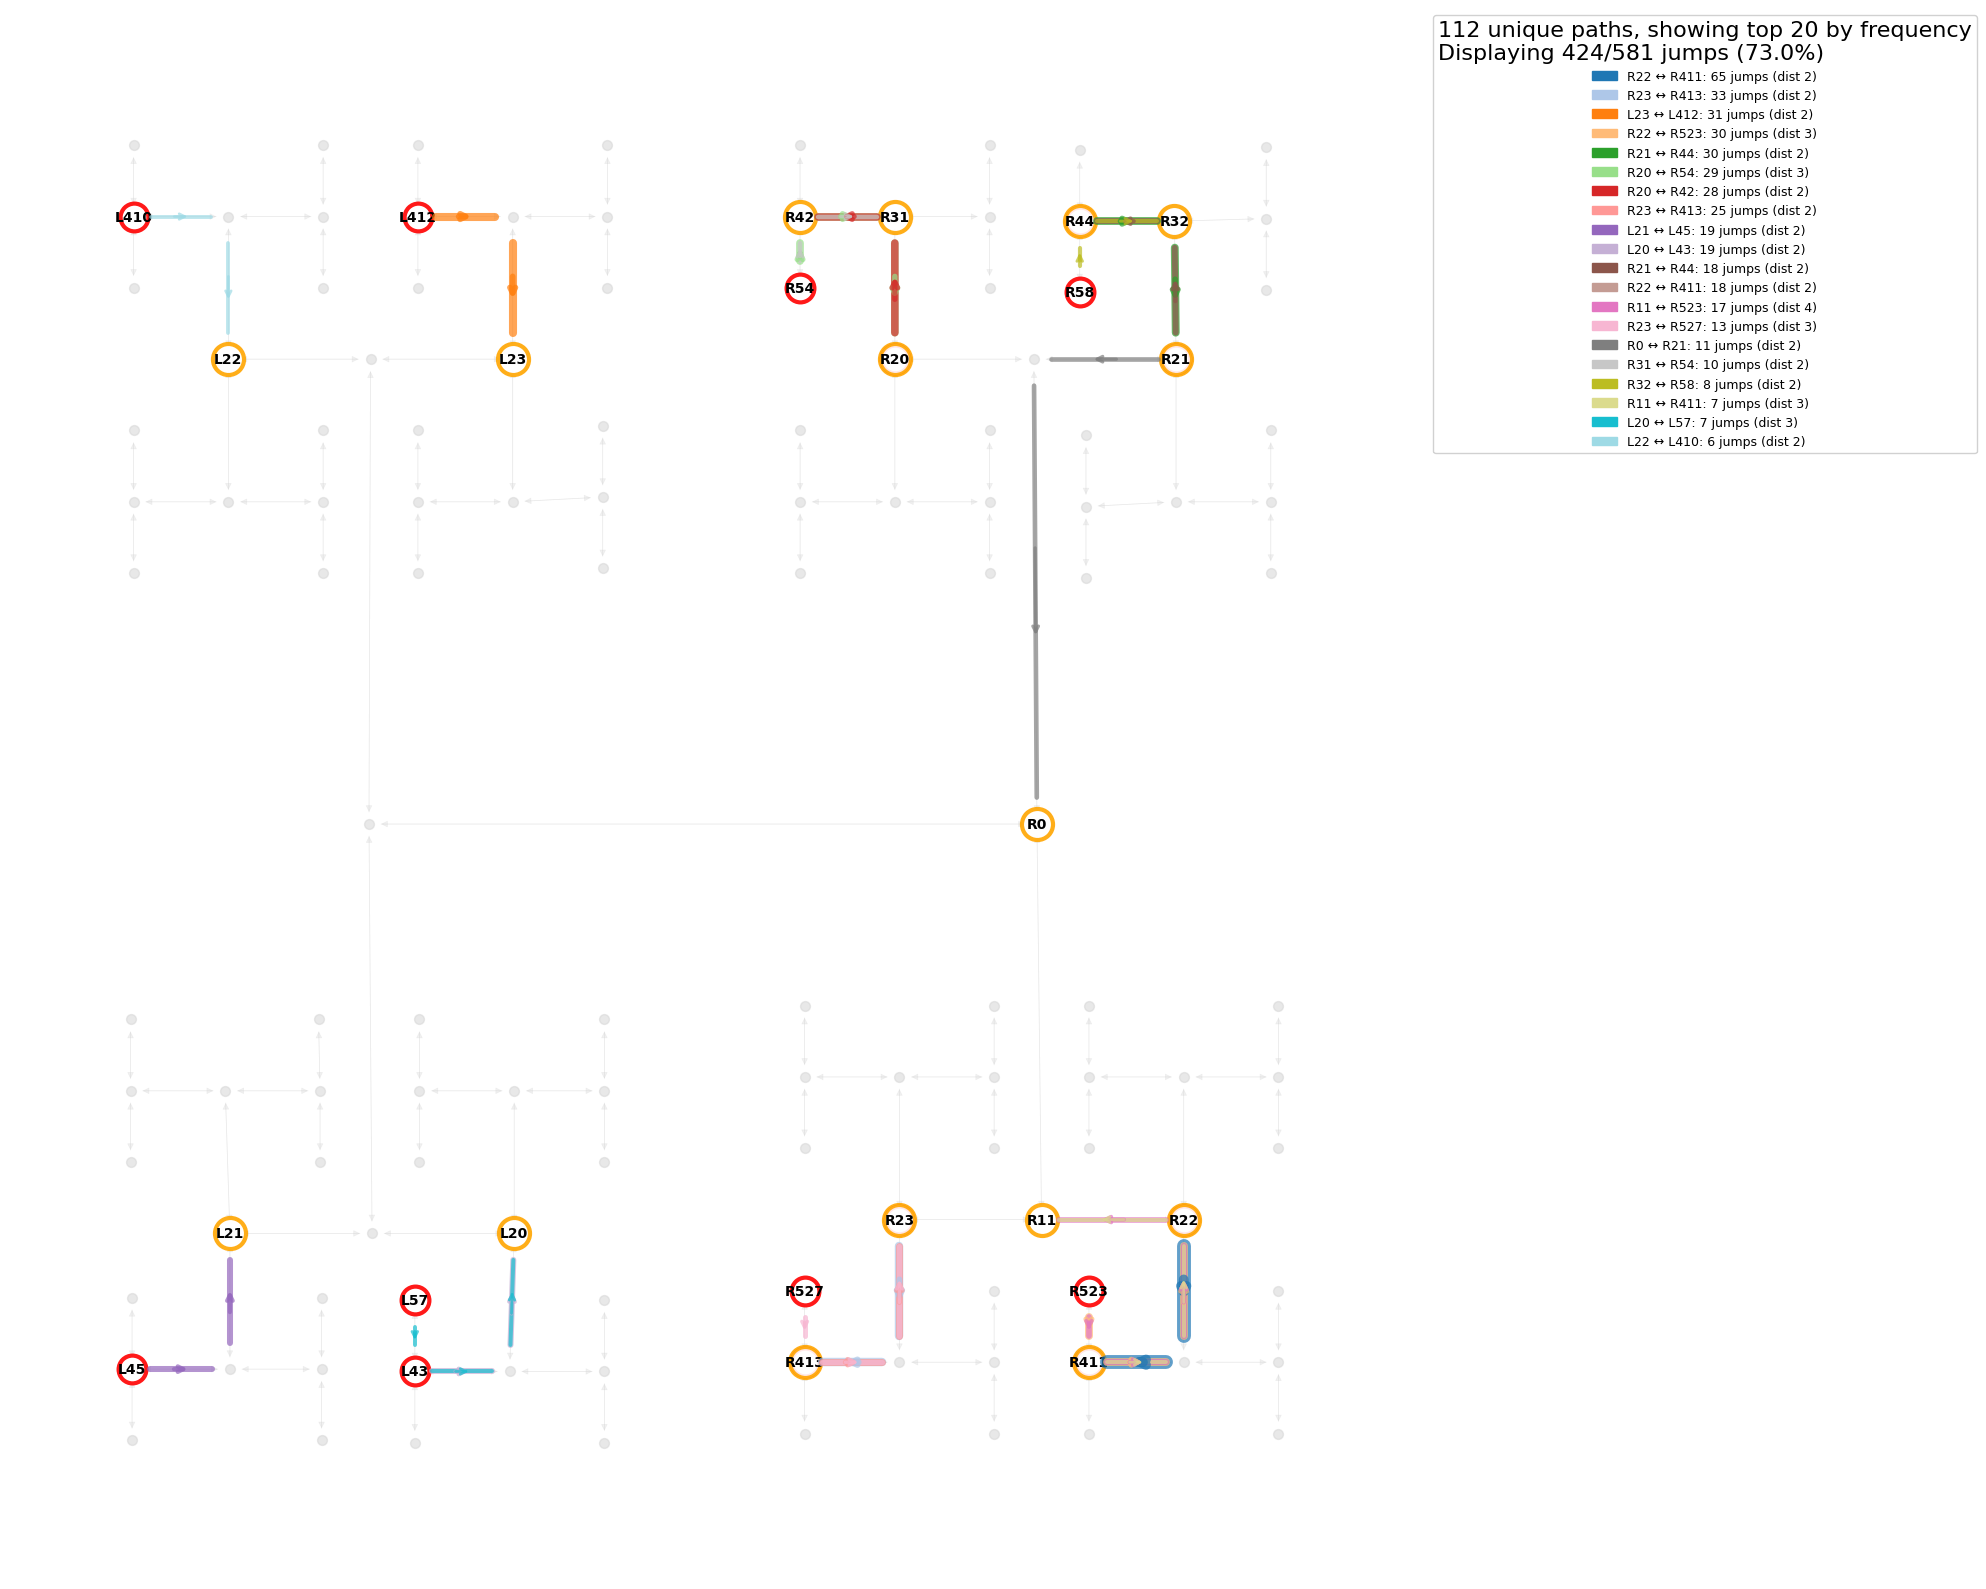


Visualization complete!
Red outlines: Jump start nodes
Orange outlines: Jump destination nodes
Showing 424/581 jumps (73.0%) in top 20 paths
No jump path data available for visualization


In [38]:
# Visualize jump paths with inferred trajectories
# Color-code by path, show frequency

if jump_path_data:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # Draw base graph structure (light gray)
    nx.draw_networkx_edges(graph, node_positions,
                          edge_color='lightgray',
                          width=0.5,
                          alpha=0.3,
                          ax=ax)
    
    # Draw base nodes (small, light)
    nx.draw_networkx_nodes(graph, node_positions,
                          node_color='lightgray',
                          node_size=50,
                          alpha=0.5,
                          ax=ax)
    
    # Prepare colors for different paths
    # Use distinct colors for most frequent paths
    num_paths_to_show = min(20, len(jump_path_data))  # Show top 15 paths
    colors = cm.tab20(np.linspace(0, 1, num_paths_to_show))
    
    # Track nodes involved in jumps for highlighting
    jump_start_nodes = set()
    jump_end_nodes = set()
    
    # Calculate total jumps and percentage shown
    total_jumps = sum(data['count'] for _, data in jump_path_data)
    shown_jumps = sum(jump_path_data[i][1]['count'] for i in range(num_paths_to_show))
    percentage_shown = (shown_jumps / total_jumps * 100) if total_jumps > 0 else 0
    
    # Draw each jump path
    legend_entries = []
    
    for path_idx in range(num_paths_to_show):
        (node_pair, path_seq), data = jump_path_data[path_idx]
        count = data['count']
        path = list(path_seq)
        color = colors[path_idx]
        
        # Track start/end nodes
        jump_start_nodes.add(path[0])
        jump_end_nodes.add(path[-1])
        
        # Draw the path edges with increasing width based on frequency
        edge_width = 2 + (count / max(p[1]['count'] for p in jump_path_data[:num_paths_to_show])) * 8
        
        for i in range(len(path) - 1):
            from_node = path[i]
            to_node = path[i+1]
            
            if from_node in node_positions and to_node in node_positions:
                from_pos = np.array(node_positions[from_node])
                to_pos = np.array(node_positions[to_node])
                
                # Calculate direction vector and offset edges from node centers
                direction = to_pos - from_pos
                distance = np.linalg.norm(direction)
                if distance > 0:
                    direction_norm = direction / distance
                    offset = 12  # pixels offset from node center
                    from_pos_offset = from_pos + direction_norm * offset
                    to_pos_offset = to_pos - direction_norm * offset
                else:
                    from_pos_offset = from_pos
                    to_pos_offset = to_pos
                
                # Draw edge with offset
                ax.plot([from_pos_offset[0], to_pos_offset[0]], 
                       [from_pos_offset[1], to_pos_offset[1]],
                       color=color,
                       linewidth=edge_width,
                       alpha=0.7,
                       solid_capstyle='round',
                       zorder=5)
                
                # Add arrow in the middle
                mid_x = (from_pos[0] + to_pos[0]) / 2
                mid_y = (from_pos[1] + to_pos[1]) / 2
                dx = to_pos[0] - from_pos[0]
                dy = to_pos[1] - from_pos[1]
                
                ax.annotate('', 
                           xy=(mid_x + dx*0.1, mid_y + dy*0.1),
                           xytext=(mid_x - dx*0.1, mid_y - dy*0.1),
                           arrowprops=dict(arrowstyle='->', 
                                         color=color,
                                         lw=edge_width*0.7,
                                         alpha=0.7),
                           zorder=6)
        
        # Create legend entry
        label = f"{node_pair[0]} ↔ {node_pair[1]}: {count} jumps (dist {len(path)-1})"
        legend_entries.append(mpatches.Patch(color=color, label=label))
    
    # Highlight start nodes (larger, outlined)
    if jump_start_nodes:
        start_positions = {n: node_positions[n] for n in jump_start_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, start_positions,
                              nodelist=list(jump_start_nodes),
                              node_color='white',
                              node_size=400,
                              edgecolors='red',
                              linewidths=3,
                              alpha=0.9,
                              ax=ax)
    
    # Highlight end nodes (larger, outlined)
    if jump_end_nodes:
        end_positions = {n: node_positions[n] for n in jump_end_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, end_positions,
                              nodelist=list(jump_end_nodes),
                              node_color='white',
                              node_size=500,
                              edgecolors='orange',
                              linewidths=3,
                              alpha=0.9,
                              ax=ax)
    
    # Draw node labels for jump nodes LAST so they appear on top
    jump_nodes = jump_start_nodes | jump_end_nodes
    jump_labels = {n: n for n in jump_nodes if n in node_positions}
    nx.draw_networkx_labels(graph, node_positions,
                           labels=jump_labels,
                           font_size=10,
                           font_weight='bold',
                           font_color='black',
                           ax=ax)
    
    # Add legend
    ax.legend(handles=legend_entries,
             loc='upper left',
             bbox_to_anchor=(1.02, 1),
             fontsize=9,
             title=f'{len(jump_path_data)} unique paths, showing top {num_paths_to_show} by frequency\n'
                   f'Displaying {shown_jumps}/{total_jumps} jumps ({percentage_shown:.1f}%)',
             title_fontsize=16,
             framealpha=0.9)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualization complete!")
    print(f"Red outlines: Jump start nodes")
    print(f"Orange outlines: Jump destination nodes")
    print(f"Showing {shown_jumps}/{total_jumps} jumps ({percentage_shown:.1f}%) in top {num_paths_to_show} paths")
    print("No jump path data available for visualization")


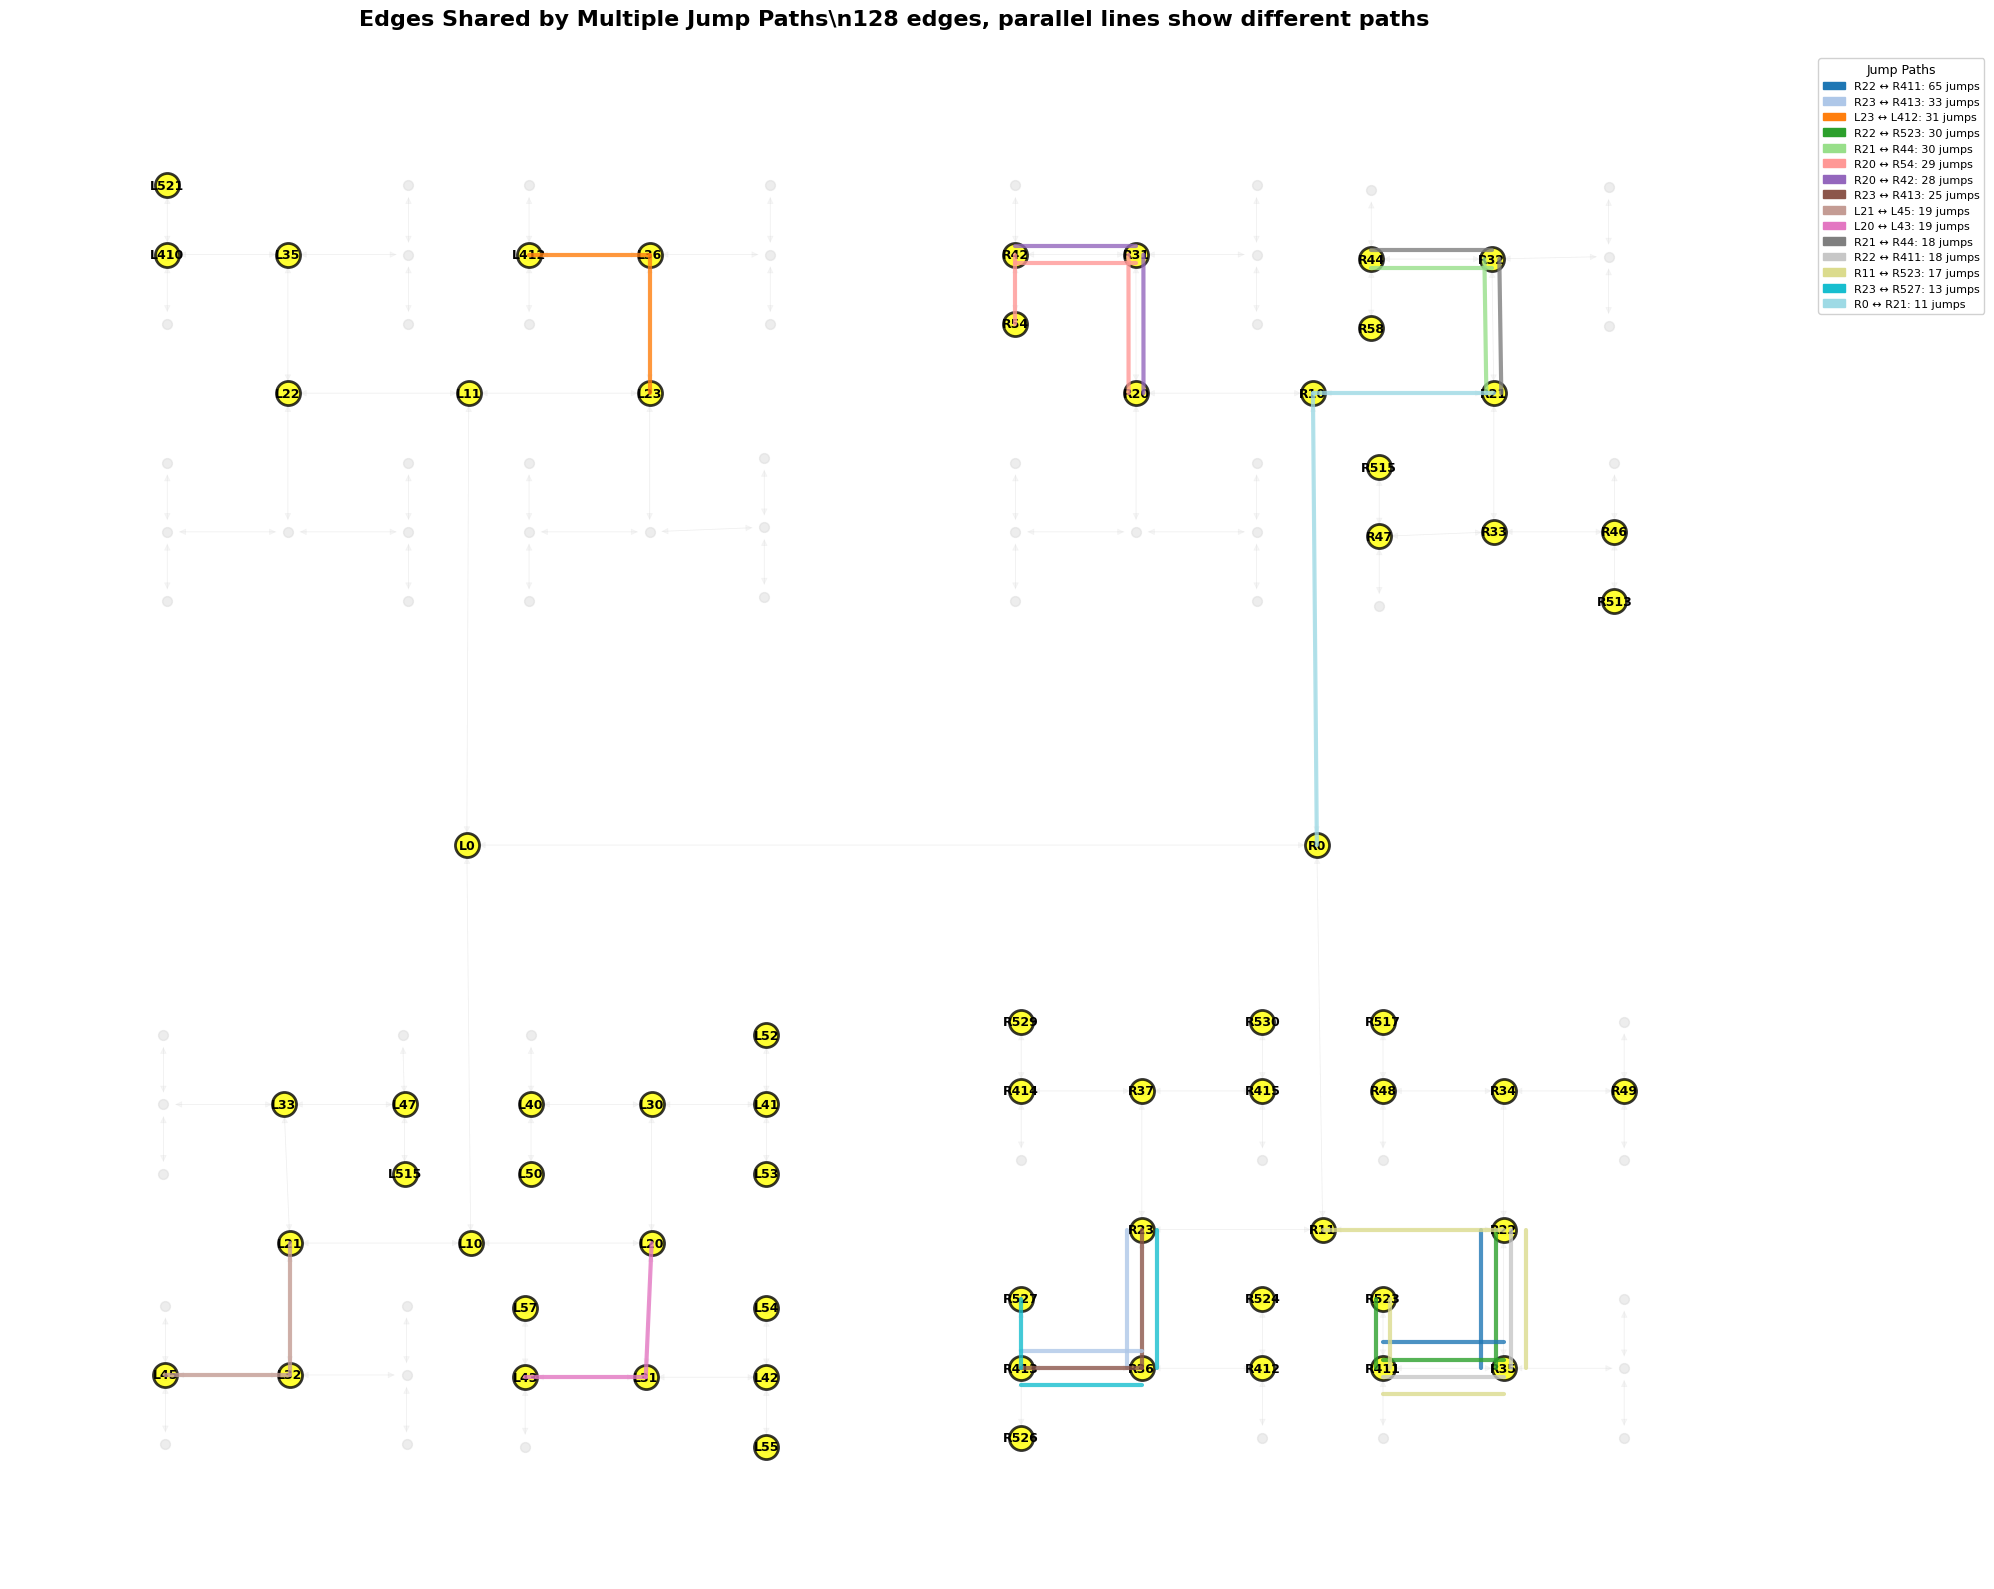

Yellow nodes: Intersection points used by multiple jump paths


In [39]:
# Alternative visualization: Show edges that are part of multiple paths
# with different colors for each path

if jump_path_data and multi_path_edges:
    fig, ax = plt.subplots(figsize=(20, 16))
    
    # Draw base graph structure
    nx.draw_networkx_edges(graph, node_positions,
                          edge_color='lightgray',
                          width=0.5,
                          alpha=0.2,
                          ax=ax)
    
    nx.draw_networkx_nodes(graph, node_positions,
                          node_color='lightgray',
                          node_size=50,
                          alpha=0.4,
                          ax=ax)
    
    # For each edge that's part of multiple paths, draw it with multiple colors
    # Use offset parallel lines for each path
    
    num_paths_to_show = min(15, len(jump_path_data))
    colors = cm.tab20(np.linspace(0, 1, num_paths_to_show))
    
    # Track which edges to draw with offsets
    edges_drawn = set()
    
    for edge, path_list in multi_path_edges.items():
        if edge in edges_drawn or (edge[1], edge[0]) in edges_drawn:
            continue
            
        unique_paths = {}
        for p in path_list:
            if p['path_idx'] < num_paths_to_show:
                unique_paths[p['path_idx']] = p
        
        if not unique_paths:
            continue
        
        from_node, to_node = edge
        if from_node not in node_positions or to_node not in node_positions:
            continue
            
        from_pos = np.array(node_positions[from_node])
        to_pos = np.array(node_positions[to_node])
        
        # Calculate perpendicular offset direction
        edge_vec = to_pos - from_pos
        edge_len = np.linalg.norm(edge_vec)
        if edge_len == 0:
            continue
            
        edge_dir = edge_vec / edge_len
        perp_dir = np.array([-edge_dir[1], edge_dir[0]])  # Perpendicular
        
        # Draw each path's contribution to this edge
        num_unique_paths = len(unique_paths)
        offset_step = 8  # pixels
        
        for i, (path_idx, path_info) in enumerate(sorted(unique_paths.items())):
            # Calculate offset position
            offset = (i - (num_unique_paths - 1) / 2) * offset_step
            
            offset_from = from_pos + perp_dir * offset
            offset_to = to_pos + perp_dir * offset
            
            color = colors[path_idx]
            width = 3
            
            # Draw the offset edge
            ax.plot([offset_from[0], offset_to[0]],
                   [offset_from[1], offset_to[1]],
                   color=color,
                   linewidth=width,
                   alpha=0.8,
                   solid_capstyle='round',
                   zorder=5)
        
        edges_drawn.add(edge)
    
    # Highlight nodes involved in shared edges
    shared_edge_nodes = set()
    for edge in multi_path_edges.keys():
        shared_edge_nodes.add(edge[0])
        shared_edge_nodes.add(edge[1])
    
    if shared_edge_nodes:
        shared_positions = {n: node_positions[n] for n in shared_edge_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, shared_positions,
                              nodelist=list(shared_edge_nodes),
                              node_color='yellow',
                              node_size=300,
                              edgecolors='black',
                              linewidths=2,
                              alpha=0.8,
                              ax=ax)
        
        # Draw labels LAST so they appear on top
        labels = {n: n for n in shared_edge_nodes if n in node_positions}
        nx.draw_networkx_labels(graph, node_positions,
                               labels=labels,
                               font_size=9,
                               font_weight='bold',
                               ax=ax)
    
    # Legend
    legend_entries = []
    for path_idx in range(num_paths_to_show):
        (node_pair, path_seq), data = jump_path_data[path_idx]
        count = data['count']
        label = f"{node_pair[0]} ↔ {node_pair[1]}: {count} jumps"
        legend_entries.append(mpatches.Patch(color=colors[path_idx], label=label))
    
    ax.legend(handles=legend_entries,
             loc='upper left',
             bbox_to_anchor=(1.02, 1),
             fontsize=8,
             title='Jump Paths',
             title_fontsize=9,
             framealpha=0.9)
    
    ax.set_title(f'Edges Shared by Multiple Jump Paths\\n'
                f'{len(multi_path_edges)} edges, parallel lines show different paths',
                fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Yellow nodes: Intersection points used by multiple jump paths")
else:
    print("No multi-path edge data available")

## Extract Direct Path Sequences Between Two Nodes

This section provides functionality to extract sequences of direct transitions between two specified nodes. The function finds all continuous sequences where the animal alternates between the two nodes until an indirect path occurs.

In [73]:
def extract_node_sequences(trav_data, node_a, node_b, graph):
    """
    Extract all sequences where the animal alternates between two nodes following the shortest path.
    Allows oscillations between the last two nodes without breaking the sequence.
    
    Args:
        trav_data: Traversal data dictionary
        node_a: First node ID
        node_b: Second node ID
        graph: NetworkX graph containing the nodes
        
    Returns:
        List of dictionaries containing sequence information
    """
    if not trav_data or 'traversal_sequence' not in trav_data:
        return []
    
    sequence = trav_data['traversal_sequence']
    sequences = []
    
    # Calculate shortest path between the two nodes
    try:
        shortest_path_a_to_b = nx.shortest_path(graph, node_a, node_b)
        shortest_path_b_to_a = list(reversed(shortest_path_a_to_b))
        path_length = len(shortest_path_a_to_b)
    except nx.NetworkXNoPath:
        print(f"No path exists between {node_a} and {node_b}")
        return []
    
    # Extract only node positions from sequence
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    # Get the last two nodes for each direction
    last_two_a_to_b = set(shortest_path_a_to_b[-2:])
    last_two_b_to_a = set(shortest_path_b_to_a[-2:])
    
    # Find all path matches first
    def find_all_matches():
        """Find all positions where the path matches in either direction"""
        matches = []
        for i in range(len(node_names) - path_length + 1):
            subseq = node_names[i:i + path_length]
            if subseq == shortest_path_a_to_b:
                matches.append((i, 'a_to_b'))
            elif subseq == shortest_path_b_to_a:
                matches.append((i, 'b_to_a'))
        return matches
    
    all_matches = find_all_matches()
    if not all_matches:
        return []
    
    # Now build sequences by looking for alternations
    used_matches = set()
    
    for start_idx in range(len(all_matches)):
        if start_idx in used_matches:
            continue
        
        # Start a new sequence - store match indices and gaps
        seq_match_info = [(start_idx, None)]  # (match_idx, gap_range)
        used_matches.add(start_idx)
        last_direction = all_matches[start_idx][1]
        last_pos = all_matches[start_idx][0]
        
        # Look for alternations from this starting point
        search_idx = start_idx + 1
        while search_idx < len(all_matches):
            curr_pos, curr_direction = all_matches[search_idx]
            
            # Check if this is an alternation (opposite direction)
            if curr_direction != last_direction:
                # Check gap from last match
                gap_start = last_pos + path_length
                gap_end = curr_pos
                gap = gap_end - gap_start
                
                # Allow:
                # - Overlapping paths (gap < 0)
                # - Direct continuation (gap == 0)
                # - Small gaps filled with oscillations between last two nodes (gap <= 20)
                if gap <= 20:
                    # If there's a gap, verify it's filled with last-two-nodes oscillations
                    gap_range = None
                    if gap > 0:
                        gap_nodes = node_names[gap_start:gap_end]
                        current_last_two = last_two_a_to_b if last_direction == 'a_to_b' else last_two_b_to_a
                        
                        # Check if all gap nodes are in the last two nodes set
                        if not all(n in current_last_two for n in gap_nodes):
                            # Gap contains other nodes, sequence ends
                            break
                        # Store gap range to include these nodes later
                        gap_range = (gap_start, gap_end)
                    
                    # Valid alternation
                    seq_match_info.append((search_idx, gap_range))
                    used_matches.add(search_idx)
                    last_direction = curr_direction
                    last_pos = curr_pos
                    search_idx += 1
                else:
                    # Gap too large, sequence ends
                    break
            else:
                # Same direction, not an alternation
                search_idx += 1
        
        # Only save sequences with at least 2 traversals
        if len(seq_match_info) >= 2:
            # Build the sequence data including gap nodes
            all_positions = []
            all_nodes = []
            
            for idx, (match_idx, gap_range) in enumerate(seq_match_info):
                pos, direction = all_matches[match_idx]
                match_positions = node_sequence[pos:pos + path_length]
                
                if idx == 0:
                    # First match: add all nodes
                    all_positions.extend(match_positions)
                    all_nodes.extend([p['position'] for p in match_positions])
                else:
                    # Check if there was a gap with oscillations before this match
                    if gap_range:
                        gap_start, gap_end = gap_range
                        gap_positions = node_sequence[gap_start:gap_end]
                        all_positions.extend(gap_positions)
                        all_nodes.extend([p['position'] for p in gap_positions])
                    
                    # Now add this match's nodes
                    # Check for overlap with what we've already added
                    prev_match_idx, prev_gap = seq_match_info[idx - 1]
                    prev_pos = all_matches[prev_match_idx][0]
                    prev_end = prev_pos + path_length
                    
                    # If there was a gap, prev_end doesn't matter, start from current position
                    # If no gap, calculate overlap
                    if gap_range is None:
                        overlap = prev_end - pos
                        if overlap > 0:
                            # Skip overlapping nodes
                            match_positions = match_positions[overlap:]
                    
                    all_positions.extend(match_positions)
                    all_nodes.extend([p['position'] for p in match_positions])
            
            sequences.append({
                'sequence': all_nodes,
                'start_frame': all_positions[0]['start_frame'],
                'end_frame': all_positions[-1]['end_frame'],
                'start_time': all_positions[0]['start_frame'] / 30.0,
                'end_time': all_positions[-1]['end_frame'] / 30.0,
                'duration': (all_positions[-1]['end_frame'] - all_positions[0]['start_frame']) / 30.0,
                'num_transitions': len(seq_match_info),
                'expected_path': shortest_path_a_to_b,
                'path_length': path_length
            })
    
    return sequences

In [74]:
# Example: Extract sequences between two nodes
# Replace 'R1' and 'R2' with your desired nodes

node_a = 'R526'
node_b = 'R522'

if trav_data and 'traversal_sequence' in trav_data:
    sequences = extract_node_sequences(trav_data, node_a, node_b, graph)
    
    print("=" * 80)
    print(f"SEQUENCES BETWEEN {node_a} AND {node_b}")
    print("=" * 80)
    
    if sequences:
        expected_path = sequences[0]['expected_path']
        path_length = sequences[0]['path_length']
        
        print(f"Expected path: {' → '.join(expected_path)}")
        print(f"Path length: {path_length} nodes")
        print(f"Found {len(sequences)} sequences with alternating traversals\n")
        
        print(f"Summary Statistics:")
        total_transitions = sum(seq['num_transitions'] for seq in sequences)
        avg_transitions = total_transitions / len(sequences)
        avg_duration = sum(seq['duration'] for seq in sequences) / len(sequences)
        
        print(f"  Total back-and-forth traversals: {total_transitions}")
        print(f"  Average traversals per sequence: {avg_transitions:.1f}")
        print(f"  Average sequence duration: {avg_duration:.2f} seconds")
        
        print(f"\nDetailed Sequences:")
        print("-" * 80)
        
        for i, seq in enumerate(sequences, 1):
            # Create a compact representation of the sequence
            num_nodes_shown = min(path_length * 2, len(seq['sequence']))
            sequence_str = ' → '.join(seq['sequence'][:num_nodes_shown])
            if len(seq['sequence']) > num_nodes_shown:
                sequence_str += f" → ... → {seq['sequence'][-1]}"
            
            print(f"\nSequence {i}:")
            print(f"  Path: {sequence_str}")
            print(f"  Back-and-forth traversals: {seq['num_transitions']}")
            print(f"  Frames: {seq['start_frame']} → {seq['end_frame']}")
            print(f"  Time: {seq['start_time']:.2f}s → {seq['end_time']:.2f}s")
            print(f"  Duration: {seq['duration']:.2f} seconds")
        
        # Show full sequence for first 3 sequences
        if len(sequences) > 0:
            print(f"\n" + "=" * 80)
            print(f"FULL SEQUENCES (First 3):")
            print("=" * 80)
            for i, seq in enumerate(sequences[:3], 1):
                print(f"\nSequence {i}: {' → '.join(seq['sequence'])}")
    else:
        print(f"\nNo alternating sequences found between {node_a} and {node_b}")
        print(f"This could mean:")
        print(f"  - The nodes are never traversed following the shortest path")
        print(f"  - There are no back-and-forth patterns between these nodes")
        print(f"  - Sequences are too short (less than 2 complete traversals)")
else:
    print("No traversal sequence data available")

SEQUENCES BETWEEN R526 AND R522
Expected path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522
Path length: 9 nodes
Found 8 sequences with alternating traversals

Summary Statistics:
  Total back-and-forth traversals: 40
  Average traversals per sequence: 5.0
  Average sequence duration: 55.77 seconds

Detailed Sequences:
--------------------------------------------------------------------------------

Sequence 1:
  Path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522 → R411 → R35 → R22 → R11 → R23 → R36 → R413 → R526 → R413 → ... → R522
  Back-and-forth traversals: 3
  Frames: 18146 → 18955
  Time: 604.87s → 631.83s
  Duration: 26.97 seconds

Sequence 2:
  Path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522 → R411 → R35 → R22 → R11 → R23 → R36 → R413 → R526 → R413 → ... → R522
  Back-and-forth traversals: 3
  Frames: 19434 → 20511
  Time: 647.80s → 683.70s
  Duration: 35.90 seconds

Sequence 3:
  Path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522 

In [84]:
node_a = 'R526'
node_b = 'R522'

if trav_data and 'traversal_sequence' in trav_data:
    sequences_tol_1 = extract_node_sequences_with_tolerance(trav_data, node_a, node_b, graph, tolerance=2)    
    print("=" * 80)
    print(f"SEQUENCES BETWEEN {node_a} AND {node_b}")
    print("=" * 80)
    
    if sequences_tol_1:
        expected_path = sequences_tol_1[0]['expected_path']
        path_length = sequences_tol_1[0]['path_length']
        
        print(f"Expected path: {' → '.join(expected_path)}")
        print(f"Path length: {path_length} nodes")
        print(f"Found {len(sequences_tol_1)} sequences with alternating traversals\n")
        
        print(f"Summary Statistics:")
        total_transitions = sum(seq['num_transitions'] for seq in sequences_tol_1)
        avg_transitions = total_transitions / len(sequences_tol_1)
        avg_duration = sum(seq['duration'] for seq in sequences_tol_1) / len(sequences_tol_1)
        
        print(f"  Total back-and-forth traversals: {total_transitions}")
        print(f"  Average traversals per sequence: {avg_transitions:.1f}")
        print(f"  Average sequence duration: {avg_duration:.2f} seconds")
        
        print(f"\nDetailed Sequences:")
        print("-" * 80)
        
        for i, seq in enumerate(sequences_tol_1, 1):
            # Create a compact representation of the sequence
            num_nodes_shown = min(path_length * 2, len(seq['sequence']))
            sequence_str = ' → '.join(seq['sequence'][:num_nodes_shown])
            if len(seq['sequence']) > num_nodes_shown:
                sequence_str += f" → ... → {seq['sequence'][-1]}"
            
            print(f"\nSequence {i}:")
            print(f"  Path: {sequence_str}")
            print(f"  Back-and-forth traversals: {seq['num_transitions']}")
            print(f"  Frames: {seq['start_frame']} → {seq['end_frame']}")
            print(f"  Time: {seq['start_time']:.2f}s → {seq['end_time']:.2f}s")
            print(f"  Duration: {seq['duration']:.2f} seconds")
        
        # Show full sequence for first 3 sequences
        if len(sequences_tol_1) > 0:
            print(f"\n" + "=" * 80)
            print(f"FULL SEQUENCES (First 3):")
            print("=" * 80)
            for i, seq in enumerate(sequences[:3], 1):
                print(f"\nSequence {i}: {' → '.join(seq['sequence'])}")
    else:
        print(f"\nNo alternating sequences found between {node_a} and {node_b}")
        print(f"This could mean:")
        print(f"  - The nodes are never traversed following the shortest path")
        print(f"  - There are no back-and-forth patterns between these nodes")
        print(f"  - Sequences are too short (less than 2 complete traversals)")
else:
    print("No traversal sequence data available")


SEQUENCES BETWEEN R526 AND R522
Expected path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522
Path length: 9 nodes
Found 18 sequences with alternating traversals

Summary Statistics:
  Total back-and-forth traversals: 109
  Average traversals per sequence: 6.1
  Average sequence duration: 54.48 seconds

Detailed Sequences:
--------------------------------------------------------------------------------

Sequence 1:
  Path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522 → R411 → R523 → R411 → R35 → R22 → R11 → R23 → R36 → R413 → ... → R526
  Back-and-forth traversals: 2
  Frames: 6525 → 6879
  Time: 217.50s → 229.30s
  Duration: 11.80 seconds

Sequence 2:
  Path: R523 → R411 → R35 → R22 → R11 → R23 → R36 → R413 → R526 → R413 → R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → ... → R526
  Back-and-forth traversals: 29
  Frames: 17196 → 24908
  Time: 573.20s → 830.27s
  Duration: 257.07 seconds

Sequence 3:
  Path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R22 → R35 

In [52]:
# Diagnostic: Check what nodes are actually in the traversal sequence
node_a = 'R526'
node_b = 'R522'

if trav_data and 'traversal_sequence' in trav_data:
    import networkx as nx
    
    # Get the shortest path
    try:
        shortest_path = nx.shortest_path(graph, node_a, node_b)
        print(f"Shortest path: {' → '.join(shortest_path)}")
        print(f"Path length: {len(shortest_path)} nodes")
        print()
        
        # Extract node sequence
        sequence = trav_data['traversal_sequence']
        node_sequence = [pos for pos in sequence if pos['type'] == 'node']
        node_names = [pos['position'] for pos in node_sequence]
        
        # Search for occurrences of the path nodes
        print(f"Checking if path nodes appear in traversal sequence:")
        for path_node in shortest_path:
            count = node_names.count(path_node)
            print(f"  {path_node}: appears {count} times")
        
        print()
        
        # Look for any subsequence that matches the shortest path
        path_len = len(shortest_path)
        matches_found = []
        
        for i in range(len(node_names) - path_len + 1):
            subseq = node_names[i:i + path_len]
            if subseq == shortest_path:
                matches_found.append((i, 'forward', subseq))
            elif subseq == list(reversed(shortest_path)):
                matches_found.append((i, 'reverse', subseq))
        
        print(f"Found {len(matches_found)} exact path matches in the traversal:")
        for idx, direction, subseq in matches_found[:10]:  # Show first 10
            print(f"  Position {idx}: {direction} - {' → '.join(subseq[:3])}...{' → '.join(subseq[-3:])}")
        
        if not matches_found:
            print("\nNo exact path matches found. Let's check for partial matches:")
            # Check for partial sequences
            for start_node in [shortest_path[0], shortest_path[-1]]:
                indices = [i for i, n in enumerate(node_names) if n == start_node]
                print(f"\n  {start_node} appears at positions: {indices[:10]}")
                
                # Show what comes after the first few occurrences
                for idx in indices[:3]:
                    if idx + 5 < len(node_names):
                        context = node_names[idx:idx+5]
                        print(f"    Position {idx}: {' → '.join(context)}")
        
    except nx.NetworkXNoPath:
        print(f"No path exists between {node_a} and {node_b}")
else:
    print("No traversal data available")

Shortest path: R526 → R413 → R36 → R23 → R11 → R22 → R35 → R411 → R522
Path length: 9 nodes

Checking if path nodes appear in traversal sequence:
  R526: appears 143 times
  R413: appears 284 times
  R36: appears 242 times
  R23: appears 242 times
  R11: appears 258 times
  R22: appears 195 times
  R35: appears 184 times
  R411: appears 258 times
  R522: appears 101 times

Found 78 exact path matches in the traversal:
  Position 355: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 465: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 785: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 803: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 811: reverse - R522 → R411 → R35...R36 → R413 → R526
  Position 819: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 839: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 857: forward - R526 → R413 → R36...R35 → R411 → R522
  Position 865: reverse - R522 → R411 → R35...R36 → R413 → R526
  

In [59]:
# Debug: Check the spacing between path matches to understand sequence detection
if trav_data and 'traversal_sequence' in trav_data:
    sequence = trav_data['traversal_sequence']
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    shortest_path = nx.shortest_path(graph, node_a, node_b)
    reverse_path = list(reversed(shortest_path))
    path_length = len(shortest_path)
    
    # Find all matches
    matches = []
    for i in range(len(node_names) - path_length + 1):
        subseq = node_names[i:i + path_length]
        if subseq == shortest_path:
            matches.append((i, 'forward'))
        elif subseq == reverse_path:
            matches.append((i, 'reverse'))
    
    print(f"Found {len(matches)} path matches")
    print("\nFirst 20 matches with gaps between them:")
    for idx in range(min(20, len(matches))):
        pos, direction = matches[idx]
        if idx > 0:
            prev_pos = matches[idx-1][0] + path_length
            gap = pos - prev_pos
            print(f"  Match {idx+1}: position {pos:5d} ({direction:7s}) - gap from previous: {gap} nodes")
        else:
            print(f"  Match {idx+1}: position {pos:5d} ({direction:7s})")
    
    # Check for alternations
    print("\nAlternations (direction changes):")
    alternations = []
    for idx in range(1, len(matches)):
        if matches[idx][1] != matches[idx-1][1]:
            gap = matches[idx][0] - (matches[idx-1][0] + path_length)
            alternations.append((matches[idx-1], matches[idx], gap))
            if len(alternations) <= 20:
                print(f"  {matches[idx-1][1]:7s} at {matches[idx-1][0]} → {matches[idx][1]:7s} at {matches[idx][0]} (gap: {gap} nodes)")
    
    print(f"\nTotal alternations found: {len(alternations)}")

Found 78 path matches

First 20 matches with gaps between them:
  Match 1: position   355 (forward)
  Match 2: position   465 (forward) - gap from previous: 101 nodes
  Match 3: position   785 (forward) - gap from previous: 311 nodes
  Match 4: position   803 (forward) - gap from previous: 9 nodes
  Match 5: position   811 (reverse) - gap from previous: -1 nodes
  Match 6: position   819 (forward) - gap from previous: -1 nodes
  Match 7: position   839 (forward) - gap from previous: 11 nodes
  Match 8: position   857 (forward) - gap from previous: 9 nodes
  Match 9: position   865 (reverse) - gap from previous: -1 nodes
  Match 10: position   873 (forward) - gap from previous: -1 nodes
  Match 11: position   891 (forward) - gap from previous: 9 nodes
  Match 12: position   901 (reverse) - gap from previous: 1 nodes
  Match 13: position   909 (forward) - gap from previous: -1 nodes
  Match 14: position   917 (reverse) - gap from previous: -1 nodes
  Match 15: position   925 (forward) - 

In [75]:
# Debug: Check Sequence 3 in detail to understand the duplicate
if sequences and len(sequences) >= 3:
    seq3 = sequences[2]  # Sequence 3 (0-indexed)
    print("Sequence 3 detailed analysis:")
    print(f"Start frame: {seq3['start_frame']}, End frame: {seq3['end_frame']}")
    print(f"Number of nodes in sequence: {len(seq3['sequence'])}")
    print(f"\nLooking for duplicate consecutive nodes:")
    
    duplicates_found = []
    for i in range(len(seq3['sequence']) - 1):
        if seq3['sequence'][i] == seq3['sequence'][i+1]:
            duplicates_found.append((i, seq3['sequence'][i]))
            # Show context
            start = max(0, i-3)
            end = min(len(seq3['sequence']), i+4)
            context = ' → '.join(seq3['sequence'][start:end])
            print(f"  Duplicate at position {i}-{i+1}: {seq3['sequence'][i]}")
            print(f"  Context: {context}")
    
    if not duplicates_found:
        print("  No duplicates found! ✓")
    
    # Also check the raw traversal data for this time period
    print(f"\nChecking raw traversal data from frames {seq3['start_frame']} to {seq3['start_frame'] + 500}:")
    node_seq = [pos for pos in trav_data['traversal_sequence'] if pos['type'] == 'node']
    
    # Find nodes in the time range
    relevant_nodes = []
    for pos in node_seq:
        if seq3['start_frame'] <= pos['start_frame'] <= seq3['start_frame'] + 500:
            relevant_nodes.append(f"{pos['position']} ({pos['start_frame']})")
    
    print(f"  First 20 nodes: {' → '.join(relevant_nodes[:20])}")

Sequence 3 detailed analysis:
Start frame: 20568, End frame: 23127
Number of nodes in sequence: 59

Looking for duplicate consecutive nodes:
  No duplicates found! ✓

Checking raw traversal data from frames 20568 to 21068:
  First 20 nodes: R526 (20568) → R413 (20810) → R36 (20825) → R23 (20825) → R11 (20835) → R22 (20846) → R35 (20863) → R411 (20863) → R522 (20869) → R411 (20870) → R522 (20871)


In [ ]:
# Find all node pairs with alternating sequences
# This helps identify which pairs of nodes have interesting back-and-forth patterns
# Can analyze either just directly connected pairs or all possible pairs

if trav_data and 'traversal_sequence' in trav_data:
    from itertools import combinations
    
    print("Analyzing node pairs for alternating sequences...")
    print("=" * 80)
    
    # Option 1: Only directly connected pairs (faster)
    # Get all directly connected node pairs
    connected_pairs = set()
    for edge in graph.edges():
        # Store as sorted tuple to avoid counting (A,B) and (B,A) separately
        pair = tuple(sorted(edge))
        connected_pairs.add(pair)
    
    pairs_to_analyze = connected_pairs
    print(f"Analyzing {len(pairs_to_analyze)} directly connected node pairs...")
    
    # Option 2: All possible pairs (slower but more comprehensive)
    # Uncomment to analyze all pairs:
    # all_nodes = list(graph.nodes())
    # pairs_to_analyze = list(combinations(all_nodes, 2))
    # print(f"Analyzing all {len(pairs_to_analyze)} possible node pairs...")
    
    # Analyze each pair
    pair_sequences = {}
    for node_a, node_b in pairs_to_analyze:
        sequences = extract_node_sequences(trav_data, node_a, node_b, graph)
        if sequences:
            pair_sequences[(node_a, node_b)] = sequences
    
    if pair_sequences:
        print(f"\nFound {len(pair_sequences)} node pairs with alternating sequences")
        print("\nTop 10 pairs by number of sequences:")
        print("-" * 80)
        
        # Sort by number of sequences
        sorted_pairs = sorted(pair_sequences.items(), 
                            key=lambda x: len(x[1]), 
                            reverse=True)
        
        for i, ((node_a, node_b), sequences) in enumerate(sorted_pairs[:10], 1):
            total_transitions = sum(seq['num_transitions'] for seq in sequences)
            avg_transitions = total_transitions / len(sequences)
            total_duration = sum(seq['duration'] for seq in sequences)
            path_length = sequences[0]['path_length']
            
            print(f"{i:2d}. {node_a} ↔ {node_b}:")
            print(f"    Path length: {path_length} nodes")
            print(f"    Sequences: {len(sequences)}")
            print(f"    Total back-and-forth traversals: {total_transitions}")
            print(f"    Avg traversals/sequence: {avg_transitions:.1f}")
            print(f"    Total duration: {total_duration:.1f}s")
            print()
    else:
        print("\nNo alternating sequences found for any analyzed node pairs")
else:
    print("No traversal sequence data available")

## Save Enhanced Visualizations

Save the improved jump path visualizations to the output folder.

In [41]:
# Save enhanced jump visualizations
if jump_path_data:
    # Create output directory
    session_path = Path(results['session_results'][0]['session_path'])
    session_name = session_path.name
    output_dir = Path('resources/outputs') / f'plots_{session_name}_enhanced'
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Saving enhanced visualizations to: {output_dir}")
    print("=" * 80)
    
    # 1. Jump Paths with Inferred Trajectories
    fig, ax = plt.subplots(figsize=(20, 16))
    
    nx.draw_networkx_edges(graph, node_positions,
                          edge_color='lightgray',
                          width=0.5,
                          alpha=0.3,
                          ax=ax)
    
    nx.draw_networkx_nodes(graph, node_positions,
                          node_color='lightgray',
                          node_size=50,
                          alpha=0.5,
                          ax=ax)
    
    num_paths_to_show = min(15, len(jump_path_data))
    colors = cm.tab20(np.linspace(0, 1, num_paths_to_show))
    
    # Calculate total jumps and percentage shown
    total_jumps = sum(data['count'] for _, data in jump_path_data)
    shown_jumps = sum(jump_path_data[i][1]['count'] for i in range(num_paths_to_show))
    percentage_shown = (shown_jumps / total_jumps * 100) if total_jumps > 0 else 0
    
    jump_start_nodes = set()
    jump_end_nodes = set()
    legend_entries = []
    
    for path_idx in range(num_paths_to_show):
        (node_pair, path_seq), data = jump_path_data[path_idx]
        count = data['count']
        path = list(path_seq)
        color = colors[path_idx]
        
        jump_start_nodes.add(path[0])
        jump_end_nodes.add(path[-1])
        
        edge_width = 2 + (count / max(p[1]['count'] for p in jump_path_data[:num_paths_to_show])) * 8
        
        for i in range(len(path) - 1):
            from_node = path[i]
            to_node = path[i+1]
            
            if from_node in node_positions and to_node in node_positions:
                from_pos = np.array(node_positions[from_node])
                to_pos = np.array(node_positions[to_node])
                
                # Calculate direction vector and offset edges from node centers
                direction = to_pos - from_pos
                distance = np.linalg.norm(direction)
                if distance > 0:
                    direction_norm = direction / distance
                    offset = 25  # pixels offset from node center
                    from_pos_offset = from_pos + direction_norm * offset
                    to_pos_offset = to_pos - direction_norm * offset
                else:
                    from_pos_offset = from_pos
                    to_pos_offset = to_pos
                
                ax.plot([from_pos_offset[0], to_pos_offset[0]], 
                       [from_pos_offset[1], to_pos_offset[1]],
                       color=color,
                       linewidth=edge_width,
                       alpha=0.7,
                       solid_capstyle='round',
                       zorder=5)
                
                mid_x = (from_pos[0] + to_pos[0]) / 2
                mid_y = (from_pos[1] + to_pos[1]) / 2
                dx = to_pos[0] - from_pos[0]
                dy = to_pos[1] - from_pos[1]
                
                ax.annotate('', 
                           xy=(mid_x + dx*0.1, mid_y + dy*0.1),
                           xytext=(mid_x - dx*0.1, mid_y - dy*0.1),
                           arrowprops=dict(arrowstyle='->', 
                                         color=color,
                                         lw=edge_width*0.7,
                                         alpha=0.7),
                           zorder=6)
        
        label = f"{node_pair[0]} ↔ {node_pair[1]}: {count} jumps (dist {len(path)-1})"
        legend_entries.append(mpatches.Patch(color=color, label=label))
    
    if jump_start_nodes:
        start_positions = {n: node_positions[n] for n in jump_start_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, start_positions,
                              nodelist=list(jump_start_nodes),
                              node_color='white',
                              node_size=400,
                              edgecolors='red',
                              linewidths=3,
                              alpha=0.9,
                              ax=ax)
    
    if jump_end_nodes:
        end_positions = {n: node_positions[n] for n in jump_end_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, end_positions,
                              nodelist=list(jump_end_nodes),
                              node_color='white',
                              node_size=400,
                              edgecolors='orange',
                              linewidths=3,
                              alpha=0.9,
                              ax=ax)
    
    # Draw labels LAST so they appear on top
    jump_nodes = jump_start_nodes | jump_end_nodes
    jump_labels = {n: n for n in jump_nodes if n in node_positions}
    nx.draw_networkx_labels(graph, node_positions,
                           labels=jump_labels,
                           font_size=10,
                           font_weight='bold',
                           font_color='black',
                           ax=ax)
    
    ax.legend(handles=legend_entries,
             loc='upper left',
             bbox_to_anchor=(1.02, 1),
             fontsize=9,
             title=f'{len(jump_path_data)} unique paths, showing top {num_paths_to_show} by frequency\n'
                   f'Displaying {shown_jumps}/{total_jumps} jumps ({percentage_shown:.1f}%)',
             title_fontsize=16,
             framealpha=0.9)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir / '01_jump_paths_inferred.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Saved: 01_jump_paths_inferred.png")
    
    # 2. Multi-path edges visualization
    if multi_path_edges:
        fig, ax = plt.subplots(figsize=(20, 16))
        
        nx.draw_networkx_edges(graph, node_positions,
                              edge_color='lightgray',
                              width=0.5,
                              alpha=0.2,
                              ax=ax)
        
        nx.draw_networkx_nodes(graph, node_positions,
                              node_color='lightgray',
                              node_size=50,
                              alpha=0.4,
                              ax=ax)
        
        edges_drawn = set()
        
        for edge, path_list in multi_path_edges.items():
            if edge in edges_drawn or (edge[1], edge[0]) in edges_drawn:
                continue
                
            unique_paths = {}
            for p in path_list:
                if p['path_idx'] < num_paths_to_show:
                    unique_paths[p['path_idx']] = p
            
            if not unique_paths:
                continue
            
            from_node, to_node = edge
            if from_node not in node_positions or to_node not in node_positions:
                continue
                
            from_pos = np.array(node_positions[from_node])
            to_pos = np.array(node_positions[to_node])
            
            edge_vec = to_pos - from_pos
            edge_len = np.linalg.norm(edge_vec)
            if edge_len == 0:
                continue
                
            edge_dir = edge_vec / edge_len
            perp_dir = np.array([-edge_dir[1], edge_dir[0]])
            
            num_unique_paths = len(unique_paths)
            offset_step = 8
            
            for i, (path_idx, path_info) in enumerate(sorted(unique_paths.items())):
                offset = (i - (num_unique_paths - 1) / 2) * offset_step
                
                offset_from = from_pos + perp_dir * offset
                offset_to = to_pos + perp_dir * offset
                
                color = colors[path_idx]
                
                ax.plot([offset_from[0], offset_to[0]],
                       [offset_from[1], offset_to[1]],
                       color=color,
                       linewidth=3,
                       alpha=0.8,
                       solid_capstyle='round',
                       zorder=5)
            
            edges_drawn.add(edge)
        
        shared_edge_nodes = set()
        for edge in multi_path_edges.keys():
            shared_edge_nodes.add(edge[0])
            shared_edge_nodes.add(edge[1])
        
        if shared_edge_nodes:
            shared_positions = {n: node_positions[n] for n in shared_edge_nodes if n in node_positions}
            nx.draw_networkx_nodes(graph, shared_positions,
                                  nodelist=list(shared_edge_nodes),
                                  node_color='yellow',
                                  node_size=300,
                                  edgecolors='black',
                                  linewidths=2,
                                  alpha=0.8,
                                  ax=ax)
            
            # Draw labels LAST so they appear on top
            labels = {n: n for n in shared_edge_nodes if n in node_positions}
            nx.draw_networkx_labels(graph, node_positions,
                                   labels=labels,
                                   font_size=9,
                                   font_weight='bold',
                                   ax=ax)
        
        legend_entries = []
        for path_idx in range(num_paths_to_show):
            (node_pair, path_seq), data = jump_path_data[path_idx]
            count = data['count']
            label = f"{node_pair[0]} ↔ {node_pair[1]}: {count} jumps"
            legend_entries.append(mpatches.Patch(color=colors[path_idx], label=label))
        
        ax.legend(handles=legend_entries,
                 loc='upper left',
                 bbox_to_anchor=(1.02, 1),
                 fontsize=8,
                 title='Jump Paths',
                 title_fontsize=9,
                 framealpha=0.9)
        
        ax.set_title(f'Edges Shared by Multiple Jump Paths\n'
                    f'{len(multi_path_edges)} edges, parallel lines show different paths',
                    fontsize=16, fontweight='bold', pad=20)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(output_dir / '02_multi_path_edges.png', dpi=300, bbox_inches='tight')
        plt.close()
        print("✓ Saved: 02_multi_path_edges.png")
    
    print("=" * 80)
    print(f"Enhanced visualizations saved to: {output_dir}")

    print(f"Total files: 2 PNG images at 300 DPI")
    print(f"Total files: 2 PNG images at 300 DPI")

Saving enhanced visualizations to: resources/outputs/plots_session_NPC1_21_08_2025_enhanced
✓ Saved: 01_jump_paths_inferred.png
✓ Saved: 01_jump_paths_inferred.png
✓ Saved: 02_multi_path_edges.png
Enhanced visualizations saved to: resources/outputs/plots_session_NPC1_21_08_2025_enhanced
Total files: 2 PNG images at 300 DPI
Total files: 2 PNG images at 300 DPI
✓ Saved: 02_multi_path_edges.png
Enhanced visualizations saved to: resources/outputs/plots_session_NPC1_21_08_2025_enhanced
Total files: 2 PNG images at 300 DPI
Total files: 2 PNG images at 300 DPI


In [65]:
# Sample the sequence
print(f"\npositions (6*40) to (6*40)+30 in traversal:")
print("-" * 70) #18146
for i, pos in enumerate(sequence[(23*40):(23*40)+60], 1):
    jump_marker = f" [JUMP {pos.get('jump_id', '?')}]" if pos['transition_type'] == 'inferred' else ""
    print(f"{i:3d}. {pos['type']:4s} | {pos['position']:12s} | "
            f"frames {pos['start_frame']:6d}-{pos['end_frame']:6d} ({pos['duration']:4d}) | "
            f"{pos['transition_type']:8s}{jump_marker}")


positions (6*40) to (6*40)+30 in traversal:
----------------------------------------------------------------------
  1. node | R411         | frames  17207- 17207 (   0) | inferred [JUMP 64]
  2. edge | R411_R35     | frames  17207- 17207 (   0) | inferred [JUMP 64]
  3. node | R35          | frames  17207- 17207 (   0) | inferred [JUMP 64]
  4. edge | R35_R22      | frames  17207- 17207 (   0) | inferred [JUMP 64]
  5. node | R22          | frames  17207- 17219 (  13) | tracked 
  6. node | R11          | frames  17220- 17232 (  13) | tracked 
  7. node | R23          | frames  17233- 17242 (  10) | tracked 
  8. node | R36          | frames  17243- 17248 (   6) | tracked 
  9. node | R413         | frames  17249- 17254 (   6) | tracked 
 10. node | R526         | frames  17255- 17933 ( 679) | tracked 
 11. node | R413         | frames  17934- 17946 (  13) | tracked 
 12. node | R526         | frames  17947- 17995 (  49) | tracked 
 13. node | R413         | frames  17996- 18005 (  1

In [77]:
def extract_node_sequences_with_tolerance(trav_data, node_a, node_b, graph, tolerance=1):
    """
    Extract sequences with tolerance for N nodes deviating from the shortest path.
    
    Args:
        trav_data: Traversal data dictionary
        node_a: First node ID
        node_b: Second node ID
        graph: NetworkX graph containing the nodes
        tolerance: Number of nodes allowed to deviate from the path (default=1)
        
    Returns:
        List of dictionaries containing sequence information
    """
    if not trav_data or 'traversal_sequence' not in trav_data:
        return []
    
    sequence = trav_data['traversal_sequence']
    sequences = []
    
    # Calculate shortest path between the two nodes
    try:
        shortest_path_a_to_b = nx.shortest_path(graph, node_a, node_b)
        shortest_path_b_to_a = list(reversed(shortest_path_a_to_b))
        path_length = len(shortest_path_a_to_b)
    except nx.NetworkXNoPath:
        print(f"No path exists between {node_a} and {node_b}")
        return []
    
    # Extract only node positions from sequence
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    # Get the last two nodes for each direction
    last_two_a_to_b = set(shortest_path_a_to_b[-2:])
    last_two_b_to_a = set(shortest_path_b_to_a[-2:])
    
    def count_deviations(subseq, expected_path):
        """Count how many nodes in subseq differ from expected_path"""
        if len(subseq) != len(expected_path):
            return float('inf')
        
        deviations = sum(1 for i in range(len(subseq)) if subseq[i] != expected_path[i])
        return deviations
    
    def get_best_match(node_list, start_idx):
        """
        Determine if sequence matches forward or backward direction within tolerance.
        Returns (direction, deviation_count) or (None, inf) if no match.
        """
        if start_idx + path_length > len(node_list):
            return None, float('inf')
        
        subseq = node_list[start_idx:start_idx + path_length]
        
        forward_dev = count_deviations(subseq, shortest_path_a_to_b)
        backward_dev = count_deviations(subseq, shortest_path_b_to_a)
        
        if forward_dev <= tolerance and forward_dev <= backward_dev:
            return 'a_to_b', forward_dev
        elif backward_dev <= tolerance:
            return 'b_to_a', backward_dev
        
        return None, float('inf')
    
    # Find all approximate path matches
    def find_all_matches():
        """Find all positions where the path approximately matches in either direction"""
        matches = []
        for i in range(len(node_names) - path_length + 1):
            direction, dev_count = get_best_match(node_names, i)
            if direction:
                matches.append((i, direction, dev_count))
        return matches
    
    all_matches = find_all_matches()
    if not all_matches:
        return []
    
    # Build sequences by looking for alternations
    used_matches = set()
    
    for start_idx in range(len(all_matches)):
        if start_idx in used_matches:
            continue
        
        # Start a new sequence
        seq_match_info = [(start_idx, None)]
        used_matches.add(start_idx)
        last_direction = all_matches[start_idx][1]
        last_pos = all_matches[start_idx][0]
        
        # Look for alternations
        search_idx = start_idx + 1
        while search_idx < len(all_matches):
            curr_pos, curr_direction, curr_dev = all_matches[search_idx]
            
            # Check if this is an alternation (opposite direction)
            if curr_direction != last_direction:
                gap_start = last_pos + path_length
                gap_end = curr_pos
                gap = gap_end - gap_start
                
                # Allow reasonable gaps with oscillations
                if gap <= 20:
                    gap_range = None
                    if gap > 0:
                        gap_nodes = node_names[gap_start:gap_end]
                        current_last_two = last_two_a_to_b if last_direction == 'a_to_b' else last_two_b_to_a
                        
                        # Check if all gap nodes are in the last two nodes set
                        if not all(n in current_last_two for n in gap_nodes):
                            break
                        gap_range = (gap_start, gap_end)
                    
                    # Valid alternation
                    seq_match_info.append((search_idx, gap_range))
                    used_matches.add(search_idx)
                    last_direction = curr_direction
                    last_pos = curr_pos
                    search_idx += 1
                else:
                    break
            else:
                search_idx += 1
        
        # Only save sequences with at least 2 traversals
        if len(seq_match_info) >= 2:
            all_positions = []
            all_nodes = []
            total_deviations = 0
            
            for idx, (match_idx, gap_range) in enumerate(seq_match_info):
                pos, direction, dev_count = all_matches[match_idx]
                total_deviations += dev_count
                match_positions = node_sequence[pos:pos + path_length]
                
                if idx == 0:
                    all_positions.extend(match_positions)
                    all_nodes.extend([p['position'] for p in match_positions])
                else:
                    if gap_range:
                        gap_start, gap_end = gap_range
                        gap_positions = node_sequence[gap_start:gap_end]
                        all_positions.extend(gap_positions)
                        all_nodes.extend([p['position'] for p in gap_positions])
                    
                    prev_match_idx, prev_gap = seq_match_info[idx - 1]
                    prev_pos = all_matches[prev_match_idx][0]
                    prev_end = prev_pos + path_length
                    
                    if gap_range is None:
                        overlap = prev_end - pos
                        if overlap > 0:
                            match_positions = match_positions[overlap:]
                    
                    all_positions.extend(match_positions)
                    all_nodes.extend([p['position'] for p in match_positions])
            
            sequences.append({
                'sequence': all_nodes,
                'start_frame': all_positions[0]['start_frame'],
                'end_frame': all_positions[-1]['end_frame'],
                'start_time': all_positions[0]['start_frame'] / 30.0,
                'end_time': all_positions[-1]['end_frame'] / 30.0,
                'duration': (all_positions[-1]['end_frame'] - all_positions[0]['start_frame']) / 30.0,
                'num_transitions': len(seq_match_info),
                'total_deviations': total_deviations,
                'expected_path': shortest_path_a_to_b,
                'path_length': path_length,
                'tolerance': tolerance
            })
    
    return sequences


# Test with different tolerance values
if trav_data and 'traversal_sequence' in trav_data:
    print("="*80)
    print(f"SEQUENCES WITH TOLERANCE ANALYSIS: {node_a} ↔ {node_b}")
    print("="*80)
    
    for tol in [0, 1, 2, 3]:
        seqs = extract_node_sequences_with_tolerance(trav_data, node_a, node_b, graph, tolerance=tol)
        
        if seqs:
            total_trans = sum(s['num_transitions'] for s in seqs)
            total_dev = sum(s['total_deviations'] for s in seqs)
            avg_trans = total_trans / len(seqs)
            avg_dur = sum(s['duration'] for s in seqs) / len(seqs)
            avg_dev = total_dev / len(seqs)
            
            print(f"\nTolerance = {tol} nodes:")
            print(f"  Sequences found: {len(seqs)}")
            print(f"  Total traversals: {total_trans}")
            print(f"  Avg traversals per sequence: {avg_trans:.1f}")
            print(f"  Avg deviations per sequence: {avg_dev:.1f}")
            print(f"  Avg duration: {avg_dur:.2f}s")
        else:
            print(f"\nTolerance = {tol} nodes:")
            print(f"  No sequences found")
    
    print("\n" + "="*80)

SEQUENCES WITH TOLERANCE ANALYSIS: R526 ↔ R522

Tolerance = 0 nodes:
  Sequences found: 8
  Total traversals: 40
  Avg traversals per sequence: 5.0
  Avg deviations per sequence: 0.0
  Avg duration: 55.77s

Tolerance = 1 nodes:
  Sequences found: 16
  Total traversals: 101
  Avg traversals per sequence: 6.3
  Avg deviations per sequence: 2.3
  Avg duration: 56.89s

Tolerance = 2 nodes:
  Sequences found: 18
  Total traversals: 109
  Avg traversals per sequence: 6.1
  Avg deviations per sequence: 2.6
  Avg duration: 54.48s

Tolerance = 3 nodes:
  Sequences found: 19
  Total traversals: 114
  Avg traversals per sequence: 6.0
  Avg deviations per sequence: 3.2
  Avg duration: 52.99s



In [64]:
# Debug: Check if there's a dataframe and what columns it has
session_data = results['session_results'][0]
print("Session data keys:", session_data.keys())

# Check if there's any dataframe info
if 'dataframe_info' in session_data:
    print(f"\nDataframe info: {session_data['dataframe_info']}")
    
# Load the CSV to see what data is actually available
csv_path = '/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-01-12_12-59-53/analysis/session_metrics_20260112_130137.csv'
try:
    df = pd.read_csv(csv_path, nrows=5)
    print(f"\nCSV columns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(df.head())
except Exception as e:
    print(f"\nError reading CSV: {e}")

Session data keys: dict_keys(['session_path', 'metrics', 'num_frames'])

CSV columns: ['session_path', 'num_frames', 'tracking_jumps', 'transition_flow']

First few rows:
                                        session_path  num_frames  \
0  /var/home/almogmeir/Documents/GitHub/NaviGraph...      139311   

                                      tracking_jumps  \
0  {'total_jumps': 10, 'jump_rate': np.float64(0....   

                                     transition_flow  
0  {'total_transitions': 2321, 'unique_nodes_visi...  


In [65]:
# # Let's load the actual session data to see what columns exist
# import sys
# sys.path.insert(0, '/var/home/almogmeir/Documents/GitHub/NaviGraph')

# from navigraph.core.session import Session
# from pathlib import Path

# # Load the session to check its dataframe columns
# session_path = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/session_NPC1_24_08_2025')
# session = Session(session_path, plugins=[])

# # Try to get the integrated dataframe
# try:
#     df_session = session.get_integrated_dataframe()
#     print(f"Dataframe shape: {df_session.shape}")
#     print(f"\nColumn names: {df_session.columns.tolist()}")
#     print(f"\nFirst few rows:")
#     print(df_session.head())
# except Exception as e:
#     print(f"Error loading dataframe: {e}")
#     import traceback
#     traceback.print_exc()

## ⚠️ Next Steps

The current pickle file has `None` values for both metrics, which means:

1. The analysis ran before the metric code was fixed
2. You need to run the analysis again to regenerate the results

**Run this command:**
```bash
cd /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree
uv run navigraph run config_dual_root.yaml --analyze
```

After running, update the pickle file path in cell 3 to the newly generated file, then run all cells below to visualize the metrics.

## Transition Flow Analysis

This section shows the complete node-to-node movement pattern throughout the session.

In [66]:
print("="*70)
print("TRANSITION FLOW SUMMARY")
print("="*70)
print(f"Total transitions: {flow['total_transitions']}")
print(f"Unique nodes visited: {flow['unique_nodes_visited']}")
print(f"Graph edges used: {len(flow['graph_edges_used'])}")
print(f"Non-edge transitions (jumps): {len(flow['non_edge_transitions'])}")
print(f"Edge coverage: {flow['edge_coverage']}% of graph edges were used")

print(f"\nMost visited nodes (Top 10):")
sorted_visits = sorted(flow['node_visit_counts'].items(), key=lambda x: x[1], reverse=True)[:10]
for node, count in sorted_visits:
    print(f"  {node}: {count} visits")

print(f"\nMost common transitions (Top 10):")
for from_node, to_node, count in flow['most_common_transitions'][:10]:
    print(f"  {from_node} → {to_node}: {count} times")

TRANSITION FLOW SUMMARY
Total transitions: 2321
Unique nodes visited: 105
Graph edges used: 80
Non-edge transitions (jumps): 10
Edge coverage: 64.0% of graph edges were used

Most visited nodes (Top 10):
  R526: 17410 visits
  L521: 10878 visits
  R522: 8603 visits
  L510: 5511 visits
  L525: 5511 visits
  R42: 4655 visits
  R411: 4024 visits
  L56: 3581 visits
  R59: 3574 visits
  R55: 2486 visits

Most common transitions (Top 10):
  R42 → R55: 237 times
  R55 → R42: 237 times
  L45 → L510: 177 times
  L510 → L45: 176 times
  R413 → R526: 142 times
  R526 → R413: 138 times
  R44 → R59: 122 times
  R59 → R44: 122 times
  L412 → L525: 112 times
  L525 → L412: 112 times


## Jump Detection Results

In [67]:
print("=" * 60)
print("GRAPH JUMP DETECTION RESULTS")
print("=" * 60)
print(f"\nTotal jumps detected: {jumps['total_jumps']}")
print(f"Jump rate: {jumps['jump_rate']:.2f} jumps/minute")

if jumps['jump_statistics']:
    stats = jumps['jump_statistics']
    print(f"\nJump Statistics:")
    print(f"  Mean distance: {stats['mean_distance']:.2f} nodes")
    print(f"  Max distance: {stats['max_distance']} nodes")
    print(f"  Most common from node: {stats['most_common_from_node']}")
    print(f"  Most common to node: {stats['most_common_to_node']}")

GRAPH JUMP DETECTION RESULTS

Total jumps detected: 10
Jump rate: 0.17 jumps/minute

Jump Statistics:
  Mean distance: 2.00 nodes
  Max distance: 2 nodes
  Most common from node: R22
  Most common to node: R411


## First 10 Jump Events

In [68]:
print(f"\nFirst 10 jump events:")
print("-" * 80)
for i, event in enumerate(jumps['jump_events'][:10], 1):
    missing = ', '.join(event['missing_nodes']) if event['missing_nodes'] else 'none'
    print(f"{i:2d}. Frame {event['frame']:6d} ({event['time_sec']:7.1f}s): "
          f"{event['from_node']:>3s} -> {event['to_node']:<3s} "
          f"(distance: {event['distance']}, skipped: {missing})")

print(f"\nTotal jump events: {len(jumps['jump_events'])}")


First 10 jump events:
--------------------------------------------------------------------------------
 1. Frame   6722 (  168.1s): R22 -> R411 (distance: 2, skipped: R35)
 2. Frame   7256 (  181.4s): R22 -> R411 (distance: 2, skipped: R35)
 3. Frame  33414 (  835.4s): R22 -> R411 (distance: 2, skipped: R35)
 4. Frame  53654 ( 1341.3s): R527 -> R36 (distance: 2, skipped: R413)
 5. Frame  56208 ( 1405.2s): R36 -> R527 (distance: 2, skipped: R413)
 6. Frame  98971 ( 2474.3s): L52 -> L53 (distance: 2, skipped: L41)
 7. Frame  98979 ( 2474.5s): L52 -> L53 (distance: 2, skipped: L41)
 8. Frame 122742 ( 3068.6s): R34 -> R517 (distance: 2, skipped: R48)
 9. Frame 127090 ( 3177.2s): R36 -> R527 (distance: 2, skipped: R413)
10. Frame 135212 ( 3380.3s): R523 -> R35 (distance: 2, skipped: R411)

Total jump events: 10


## Convert to DataFrame for Analysis

In [69]:
# Convert jump events to DataFrame
df_jumps = pd.DataFrame(jumps['jump_events'])

# Display basic info
print("Jump Events DataFrame:")
print(df_jumps.head(10))
print(f"\nShape: {df_jumps.shape}")
print(f"\nColumn types:")
print(df_jumps.dtypes)

Jump Events DataFrame:
    frame  time_sec from_node to_node  distance missing_nodes
0    6722   168.050       R22    R411         2         [R35]
1    7256   181.400       R22    R411         2         [R35]
2   33414   835.350       R22    R411         2         [R35]
3   53654  1341.350      R527     R36         2        [R413]
4   56208  1405.200       R36    R527         2        [R413]
5   98971  2474.275       L52     L53         2         [L41]
6   98979  2474.475       L52     L53         2         [L41]
7  122742  3068.550       R34    R517         2         [R48]
8  127090  3177.250       R36    R527         2        [R413]
9  135212  3380.300      R523     R35         2        [R411]

Shape: (10, 6)

Column types:
frame              int64
time_sec         float64
from_node         object
to_node           object
distance           int64
missing_nodes     object
dtype: object


## Statistical Summary

In [70]:
# Filter out infinite distances for statistics
df_finite = df_jumps[df_jumps['distance'] != float('inf')]

print("\nDistance Statistics (excluding infinite):")
print(df_finite['distance'].describe())


Distance Statistics (excluding infinite):
count    10.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50%       2.0
75%       2.0
max       2.0
Name: distance, dtype: float64


## Most Common Jump Transitions

In [71]:
print("\nMost Common Jump Transitions (Top 15):")
transition_counts = df_jumps.groupby(['from_node', 'to_node']).size().sort_values(ascending=False)
print(transition_counts.head(15))


Most Common Jump Transitions (Top 15):
from_node  to_node
R22        R411       3
L52        L53        2
R36        R527       2
R34        R517       1
R523       R35        1
R527       R36        1
dtype: int64


## Visualize Jump Distribution Over Time

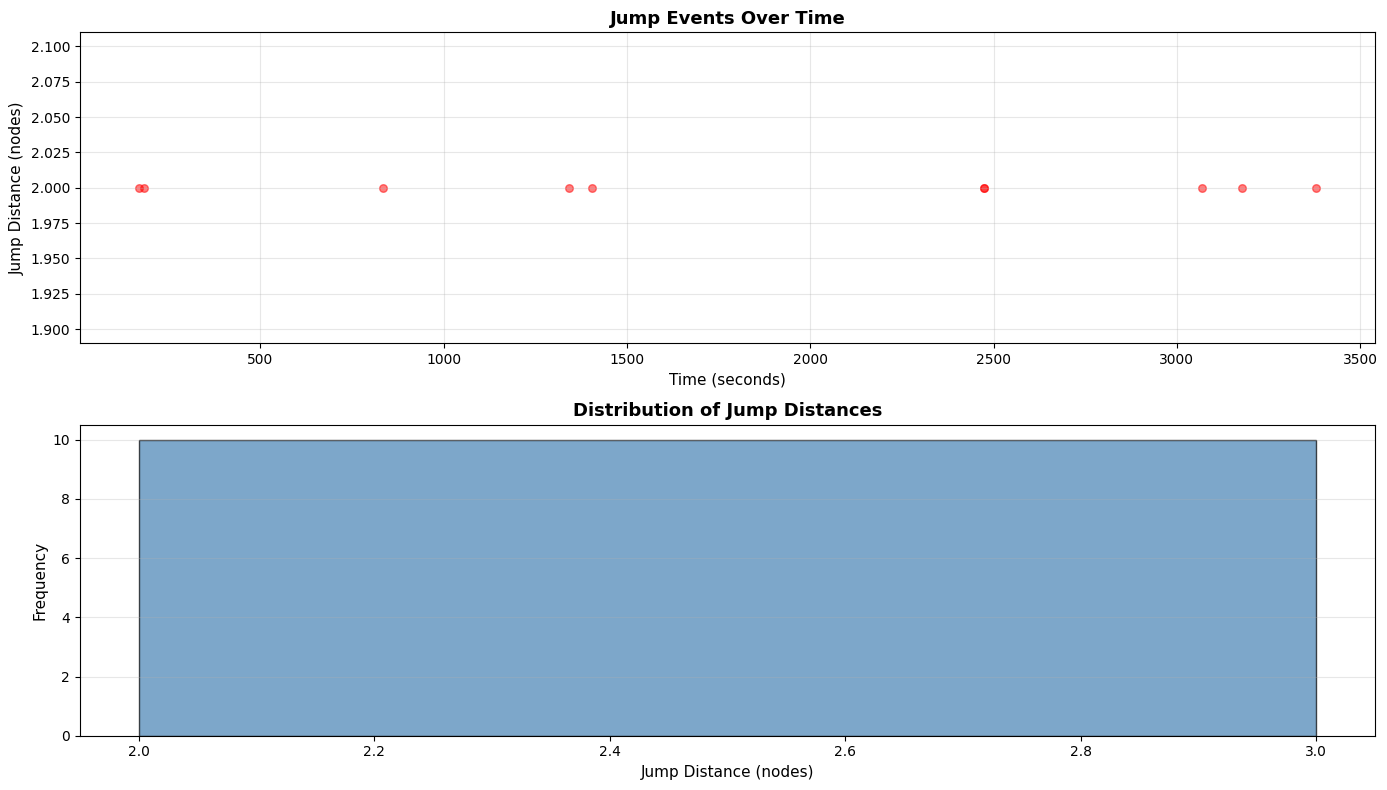


Visualization complete!


In [72]:
# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Jump events over time with distance
ax1 = axes[0]
finite_mask = df_jumps['distance'] != float('inf')
ax1.scatter(df_jumps[finite_mask]['time_sec'], 
           df_jumps[finite_mask]['distance'], 
           alpha=0.5, s=30, c='red')
ax1.set_xlabel('Time (seconds)', fontsize=11)
ax1.set_ylabel('Jump Distance (nodes)', fontsize=11)
ax1.set_title('Jump Events Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram of jump distances
ax2 = axes[1]
ax2.hist(df_jumps[finite_mask]['distance'], bins=range(2, int(df_finite['distance'].max())+2), 
        alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Jump Distance (nodes)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Jump Distances', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")

## Jump Rate Over Time Bins

/tmp/ipykernel_866734/3523600011.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jumps_per_bin = df_jumps.groupby('time_bin').size()


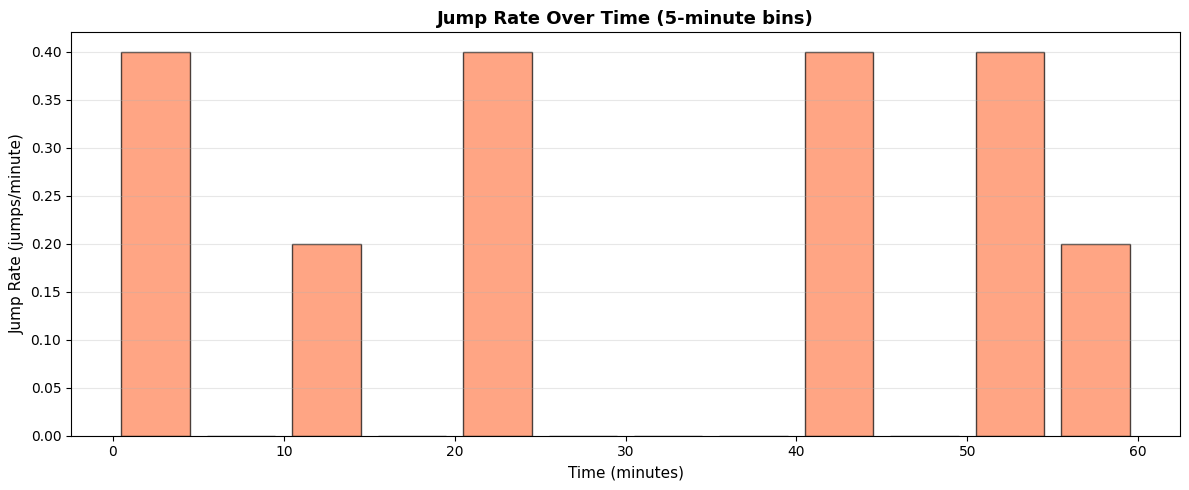


Mean jump rate: 0.17 jumps/min
Max jump rate: 0.40 jumps/min


In [73]:
# Calculate jump rate in 5-minute bins
bin_size_sec = 300  # 5 minutes
max_time = df_jumps['time_sec'].max()
bins = np.arange(0, max_time + bin_size_sec, bin_size_sec)

# Bin the jumps
df_jumps['time_bin'] = pd.cut(df_jumps['time_sec'], bins=bins)
jumps_per_bin = df_jumps.groupby('time_bin').size()
jumps_per_min = jumps_per_bin / (bin_size_sec / 60)

# Plot
plt.figure(figsize=(12, 5))
bin_centers = [(b.left + b.right) / 2 / 60 for b in jumps_per_min.index]  # Convert to minutes
plt.bar(bin_centers, jumps_per_min.values, width=(bin_size_sec/60)*0.8, 
        alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('Time (minutes)', fontsize=11)
plt.ylabel('Jump Rate (jumps/minute)', fontsize=11)
plt.title('Jump Rate Over Time (5-minute bins)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nMean jump rate: {jumps_per_min.mean():.2f} jumps/min")
print(f"Max jump rate: {jumps_per_min.max():.2f} jumps/min")

## Export Results to CSV

In [74]:
# Export the jump events to CSV for further analysis
output_csv = Path('resources/outputs/jump_events_detailed.csv')
df_jumps.to_csv(output_csv, index=False)
print(f"Jump events exported to: {output_csv}")

Jump events exported to: resources/outputs/jump_events_detailed.csv


## Visualize Jumps on Graph Structure

This section visualizes the jump locations on the actual graph structure.

In [75]:
# Load the graph structure and mapping
import pickle
import networkx as nx

# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_mappings/NPC1_2025_08_21.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# The structure is: mappings['nodes'] = {node_id: [[[x1,y1], [x2,y2], [x3,y3], [x4,y4]]], ...}
# Each node has a polygon (bounding box). We'll use the center of the bounding box.
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    # polygon_list is [[[x1,y1], [x2,y2], [x3,y3], [x4,y4]]]
    # Get the polygon points (first element of outer list)
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")
print(f"Sample nodes: {list(node_positions.keys())[:10]}")

# Build graph structure from edges_dict
# edges_dict maps "node1_node2" to polygon list
graph = nx.DiGraph()

# Add all nodes
graph.add_nodes_from(node_positions.keys())

# Add edges from edges_dict
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    # edge_key is like "R41_R52" or "L0_L11"
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            graph.add_edge(from_node, to_node)
            # Also add reverse edge for undirected navigation
            graph.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(graph.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph is ready for visualization!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions
Sample nodes: ['R49', 'R11', 'L529', 'R515', 'L510', 'L513', 'L410', 'R523', 'R41', 'L55']

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph is ready for visualization!


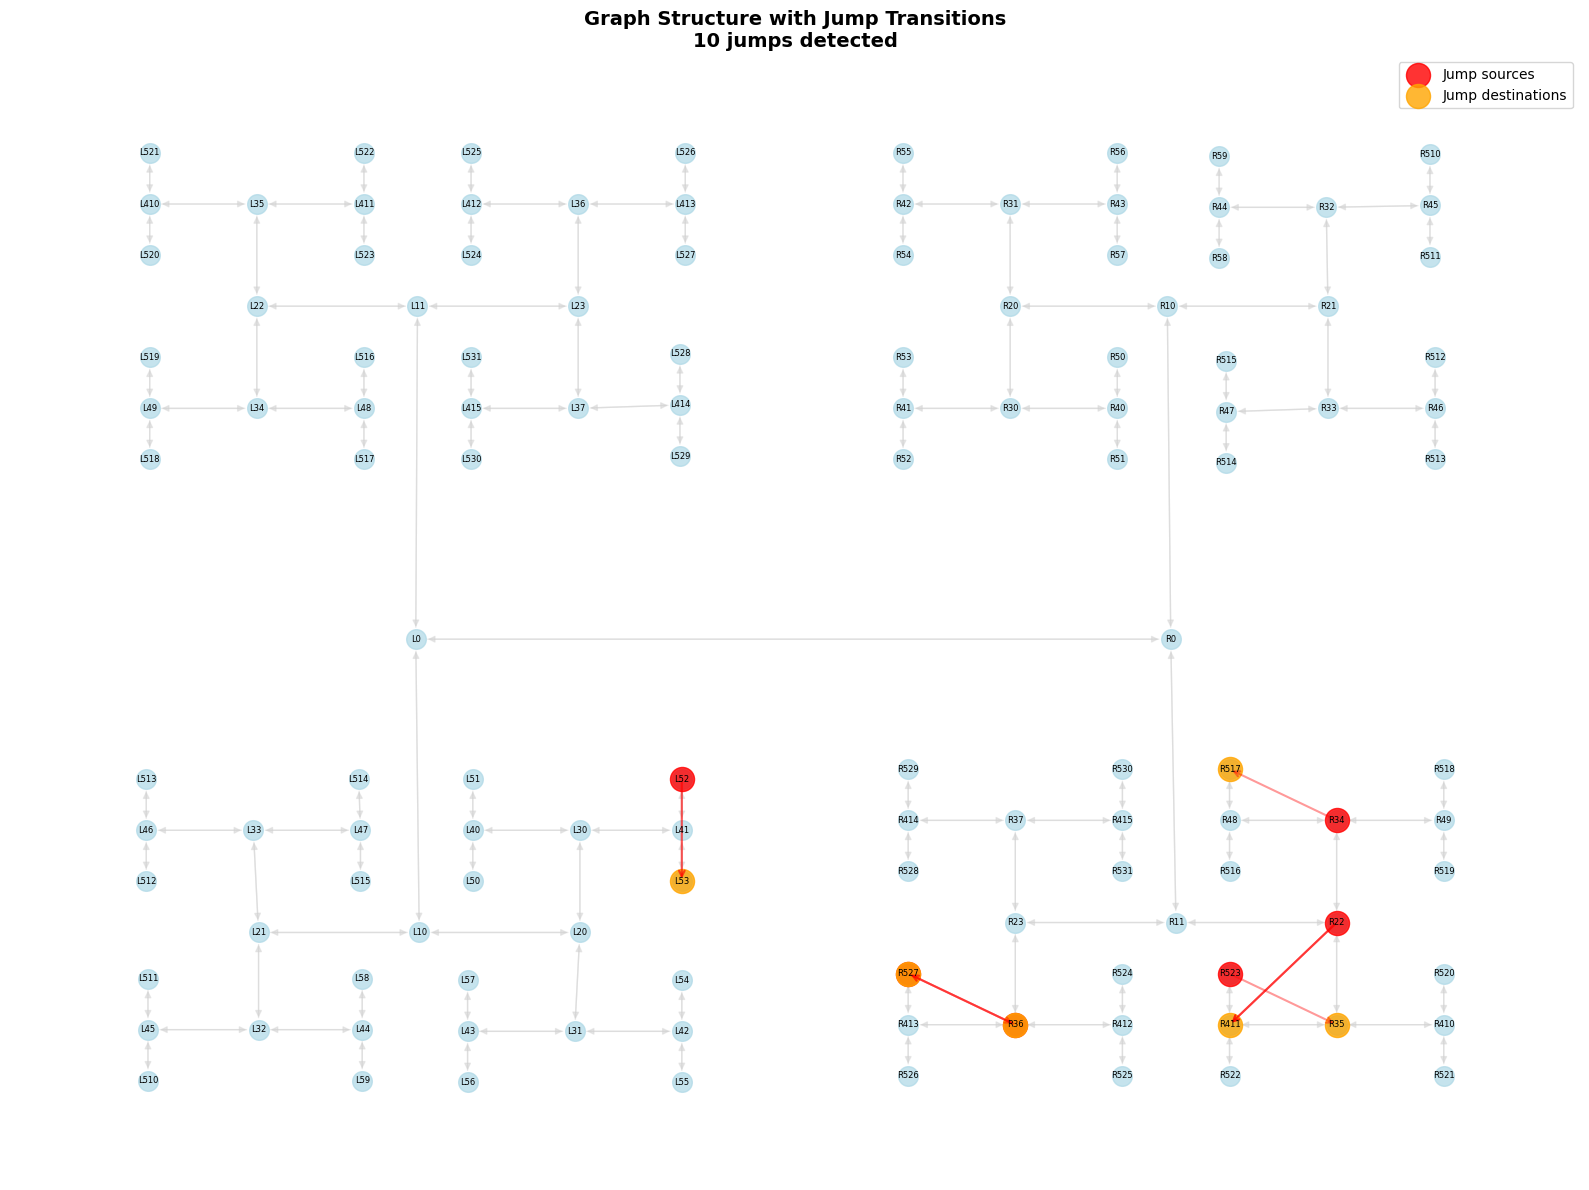

Visualization shows:
  - Red nodes: Sources of jumps (6 nodes)
  - Orange nodes: Destinations of jumps (6 nodes)
  - Red arrows: Jump transitions (showing first 100)


In [76]:
# Visualize the graph with jump transitions highlighted
fig, ax = plt.subplots(figsize=(16, 12))

# Draw all graph edges (normal transitions)
nx.draw_networkx_edges(graph, node_positions, 
                       edge_color='lightgray', 
                       width=1, 
                       alpha=0.5,
                       ax=ax)

# Draw all nodes
nx.draw_networkx_nodes(graph, node_positions,
                      node_color='lightblue',
                      node_size=200,
                      alpha=0.7,
                      ax=ax)

# Highlight nodes involved in jumps
if jumps['jump_events']:
    jump_from_nodes = set([e['from_node'] for e in jumps['jump_events']])
    jump_to_nodes = set([e['to_node'] for e in jumps['jump_events']])
    
    # Draw jump source nodes (red)
    if jump_from_nodes:
        from_pos = {n: node_positions[n] for n in jump_from_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, from_pos,
                              nodelist=list(jump_from_nodes),
                              node_color='red',
                              node_size=300,
                              alpha=0.8,
                              label='Jump sources',
                              ax=ax)
    
    # Draw jump destination nodes (orange)
    if jump_to_nodes:
        to_pos = {n: node_positions[n] for n in jump_to_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, to_pos,
                              nodelist=list(jump_to_nodes),
                              node_color='orange',
                              node_size=300,
                              alpha=0.8,
                              label='Jump destinations',
                              ax=ax)
    
    # Draw jump transitions as arrows (not following edges)
    for event in jumps['jump_events'][:100]:  # Limit to first 100 for clarity
        from_node = event['from_node']
        to_node = event['to_node']
        
        if from_node in node_positions and to_node in node_positions:
            from_pos = node_positions[from_node]
            to_pos = node_positions[to_node]
            
            ax.annotate('', xy=to_pos, xytext=from_pos,
                       arrowprops=dict(arrowstyle='->', 
                                     color='red', 
                                     lw=1.5,
                                     alpha=0.4))

# Draw node labels
nx.draw_networkx_labels(graph, node_positions,
                       font_size=6,
                       font_color='black',
                       ax=ax)

ax.set_title(f'Graph Structure with Jump Transitions\n{len(jumps["jump_events"])} jumps detected', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Visualization shows:")
print(f"  - Red nodes: Sources of jumps ({len(jump_from_nodes)} nodes)")
print(f"  - Orange nodes: Destinations of jumps ({len(jump_to_nodes)} nodes)")
print(f"  - Red arrows: Jump transitions (showing first 100)")

## Heat Map of Jump Activity by Node

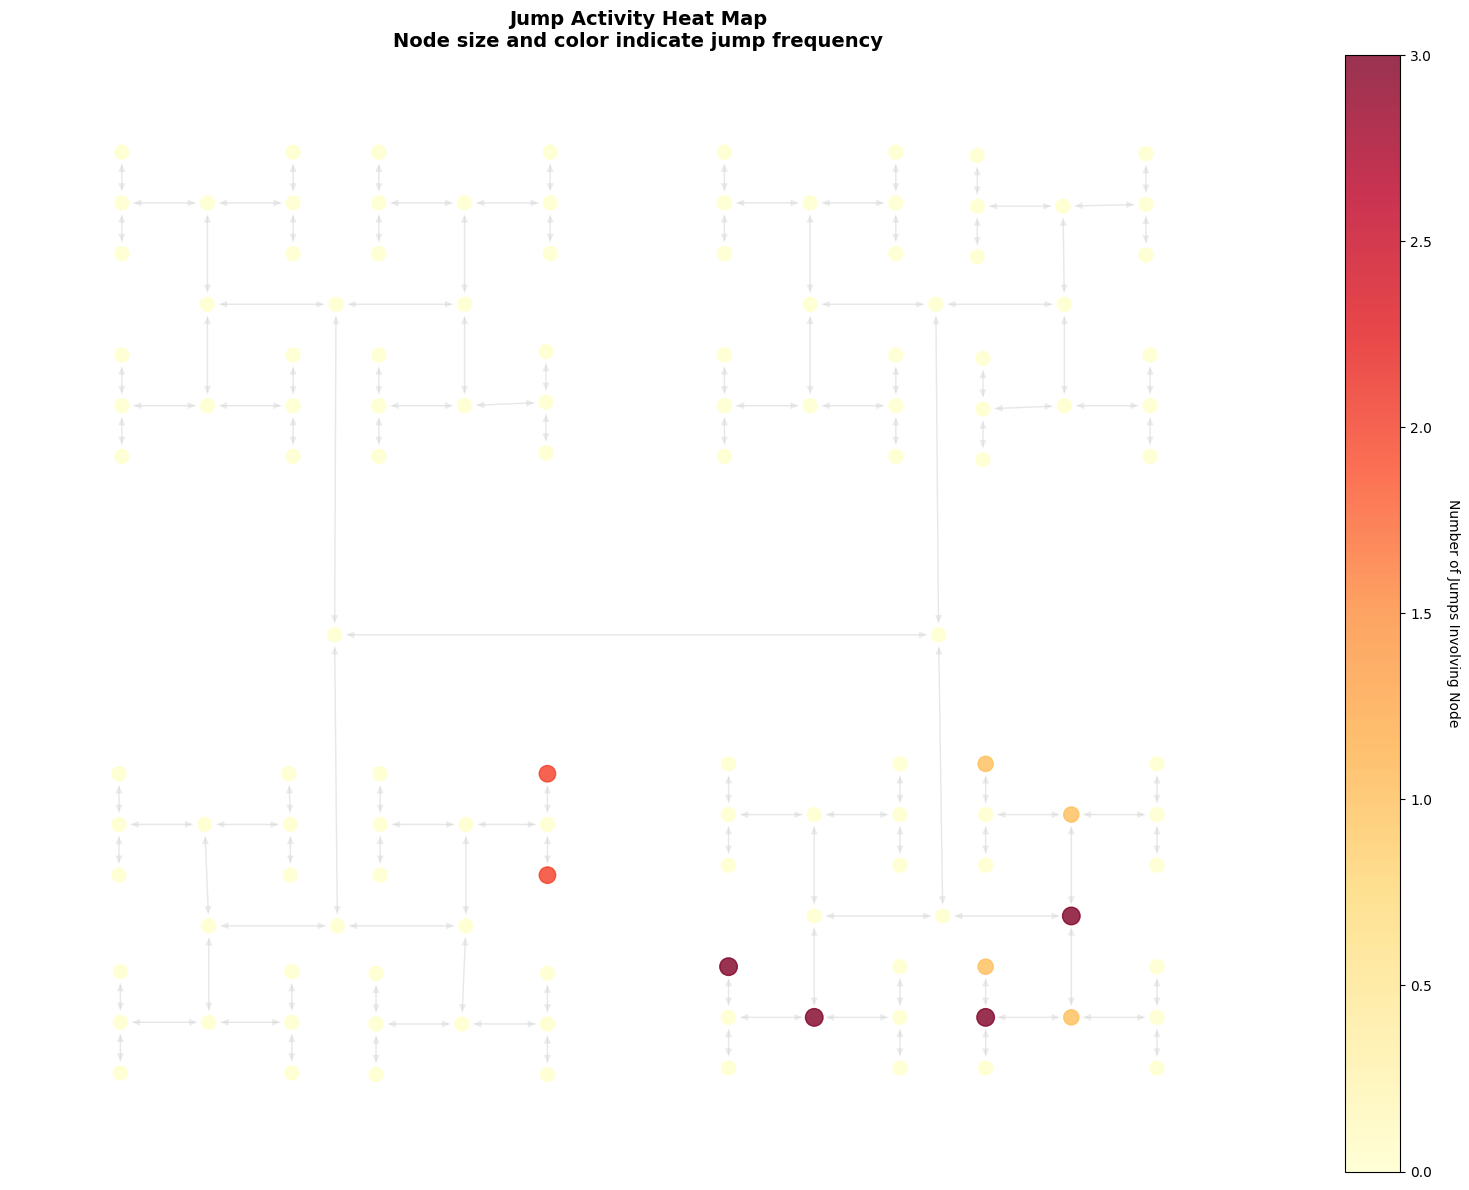

Top 10 nodes with most jump activity:
  R22: 3 jumps
  R411: 3 jumps
  R527: 3 jumps
  R36: 3 jumps
  L52: 2 jumps
  L53: 2 jumps
  R34: 1 jumps
  R517: 1 jumps
  R523: 1 jumps
  R35: 1 jumps


In [77]:
# Create a heat map showing which nodes have most jumps
from collections import Counter

# Count jumps per node (both from and to)
jump_counts = Counter()
for event in jumps['jump_events']:
    jump_counts[event['from_node']] += 1
    jump_counts[event['to_node']] += 1

# Create node colors based on jump activity
node_colors = []
node_sizes = []
for node in graph.nodes():
    count = jump_counts.get(node, 0)
    node_colors.append(count)
    node_sizes.append(100 + count * 20)  # Size proportional to jumps

# Visualize
fig, ax = plt.subplots(figsize=(16, 12))

# Draw edges
nx.draw_networkx_edges(graph, node_positions,
                       edge_color='lightgray',
                       width=1,
                       alpha=0.3,
                       ax=ax)

# Draw nodes with heat map coloring
nodes_drawn = nx.draw_networkx_nodes(graph, node_positions,
                                    node_color=node_colors,
                                    node_size=node_sizes,
                                    cmap='YlOrRd',
                                    vmin=0,
                                    vmax=max(node_colors) if node_colors else 1,
                                    alpha=0.8,
                                    ax=ax)

# Add colorbar
cbar = plt.colorbar(nodes_drawn, ax=ax)
cbar.set_label('Number of Jumps Involving Node', rotation=270, labelpad=20)

# Draw labels for high-activity nodes
high_activity_nodes = {n: c for n, c in jump_counts.items() if c > np.percentile(list(jump_counts.values()), 75)}
if high_activity_nodes:
    labels = {n: f"{n}\n({c})" for n, c in high_activity_nodes.items()}
    nx.draw_networkx_labels(graph, node_positions,
                           labels=labels,
                           font_size=7,
                           font_color='black',
                           ax=ax)

ax.set_title('Jump Activity Heat Map\nNode size and color indicate jump frequency', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Top 10 nodes with most jump activity:")
for node, count in jump_counts.most_common(10):
    print(f"  {node}: {count} jumps")

## Transition Flow Visualization

Shows the actual paths taken through the graph, with edge thickness indicating frequency.

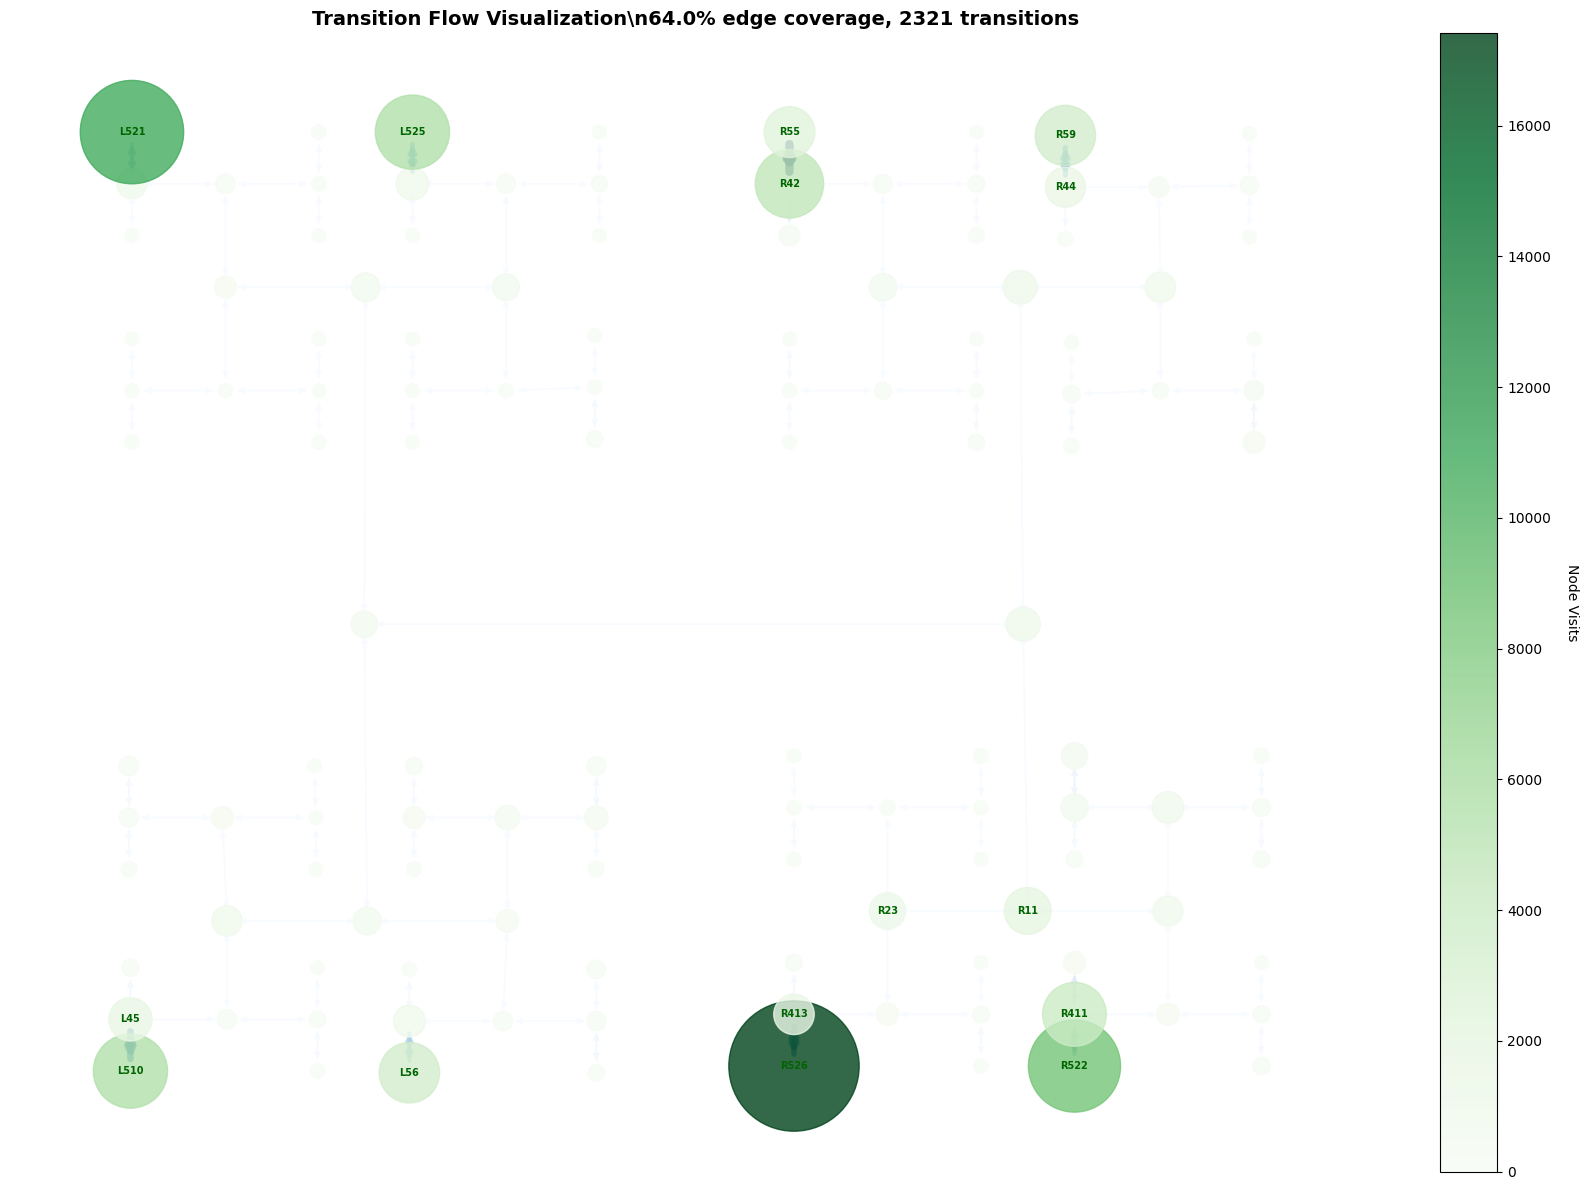

Transition statistics:
  Edges used: 80 / 250 (64.0%)
  Most used edges:
    R42 → R55: 237 times
    R55 → R42: 237 times
    L45 → L510: 177 times
    L510 → L45: 176 times
    R413 → R526: 142 times
    R526 → R413: 138 times
    R44 → R59: 122 times
    R59 → R44: 122 times
    L412 → L525: 112 times
    L525 → L412: 112 times


In [78]:
# Visualize the actual transitions taken (graph edges that were used)
fig, ax = plt.subplots(figsize=(16, 12))

# Count how many times each edge was used
edge_counts = {}
for (from_node, to_node), count in flow['transition_matrix'].items():
    # Check if this is a graph edge (not a jump)
    if graph.has_edge(from_node, to_node):
        edge_counts[(from_node, to_node)] = count

# Calculate edge widths based on usage
max_count = max(edge_counts.values()) if edge_counts else 1
edge_widths = [1 + (edge_counts.get(e, 0) / max_count) * 5 for e in graph.edges()]
edge_colors = [edge_counts.get(e, 0) for e in graph.edges()]

# Draw edges with thickness based on usage
edges = nx.draw_networkx_edges(graph, node_positions,
                               width=edge_widths,
                               edge_color=edge_colors,
                               edge_cmap=plt.cm.Blues,
                               edge_vmin=0,
                               edge_vmax=max(edge_colors) if edge_colors else 1,
                               alpha=0.7,
                               ax=ax)

# Color nodes by visit frequency
node_colors = [flow['node_visit_counts'].get(str(node), 0) for node in graph.nodes()]
node_sizes = [100 + flow['node_visit_counts'].get(str(node), 0) * 0.5 for node in graph.nodes()]

nodes = nx.draw_networkx_nodes(graph, node_positions,
                              node_color=node_colors,
                              node_size=node_sizes,
                              cmap='Greens',
                              vmin=0,
                              vmax=max(node_colors) if node_colors else 1,
                              alpha=0.8,
                              ax=ax)

# Add colorbars
cbar_nodes = plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Node Visits', rotation=270, labelpad=20)

# Draw labels for most visited nodes
top_nodes = sorted(flow['node_visit_counts'].items(), key=lambda x: x[1], reverse=True)[:15]
top_node_labels = {n: f"{n}" for n, c in top_nodes}
nx.draw_networkx_labels(graph, node_positions,
                       labels=top_node_labels,
                       font_size=7,
                       font_color='darkgreen',
                       font_weight='bold',
                       ax=ax)

ax.set_title(f'Transition Flow Visualization\\n{flow["edge_coverage"]}% edge coverage, {flow["total_transitions"]} transitions', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Transition statistics:")
print(f"  Edges used: {len(flow['graph_edges_used'])} / {len(list(graph.edges()))} ({flow['edge_coverage']}%)")
print(f"  Most used edges:")
sorted_edges = sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for (from_n, to_n), count in sorted_edges:
    print(f"    {from_n} → {to_n}: {count} times")

## Transition Flow by Unique Visits

The plots below show node sizes based on unique visits (not frame count) and edge thickness based on transition count.

In [80]:
# Count unique visits and transitions for TRACKED data only
def count_unique_visits_and_transitions(traversal_data, tracked_only=True):
    """
    Count unique visits to nodes and transitions between nodes.
    
    Args:
        traversal_data: The traversal sequence data
        tracked_only: If True, only count tracked positions; if False, include inferred
        
    Returns:
        Dictionary with node visit counts and edge transition counts
    """
    if not traversal_data or 'traversal_sequence' not in traversal_data:
        return None
    
    sequence = traversal_data['traversal_sequence']
    
    # Filter based on tracked_only parameter
    if tracked_only:
        filtered_sequence = [
            pos for pos in sequence 
            if pos.get('transition_type') == 'tracked' or 
               (pos.get('type') == 'node' and pos.get('transition_type') != 'inferred')
        ]
    else:
        filtered_sequence = sequence
    
    # Count node visits
    node_visits = {}
    prev_node = None
    
    for pos in filtered_sequence:
        if pos['type'] == 'node':
            node_id = pos['position']
            node_visits[node_id] = node_visits.get(node_id, 0) + 1
            prev_node = node_id
    
    # Count edge transitions
    edge_transitions = {}
    prev_pos = None
    
    for pos in filtered_sequence:
        if pos['type'] == 'node':
            curr_node = pos['position']
            
            if prev_pos is not None and prev_pos['type'] == 'node':
                prev_node = prev_pos['position']
                edge_key = (prev_node, curr_node)
                edge_transitions[edge_key] = edge_transitions.get(edge_key, 0) + 1
            
            prev_pos = pos
        elif pos['type'] == 'edge':
            prev_pos = pos
    
    return {
        'node_visits': node_visits,
        'edge_transitions': edge_transitions,
        'total_node_visits': sum(node_visits.values()),
        'total_transitions': sum(edge_transitions.values())
    }


# Calculate for both tracked and full traversal
tracked_counts = count_unique_visits_and_transitions(trav_data, tracked_only=True)
full_counts = count_unique_visits_and_transitions(trav_data, tracked_only=False)

print("Unique Visit Statistics:")
print(f"  Tracked only: {tracked_counts['total_node_visits']} node visits, {tracked_counts['total_transitions']} transitions")
print(f"  Full traversal: {full_counts['total_node_visits']} node visits, {full_counts['total_transitions']} transitions")

Unique Visit Statistics:
  Tracked only: 5574 node visits, 5573 transitions
  Full traversal: 6429 node visits, 4992 transitions


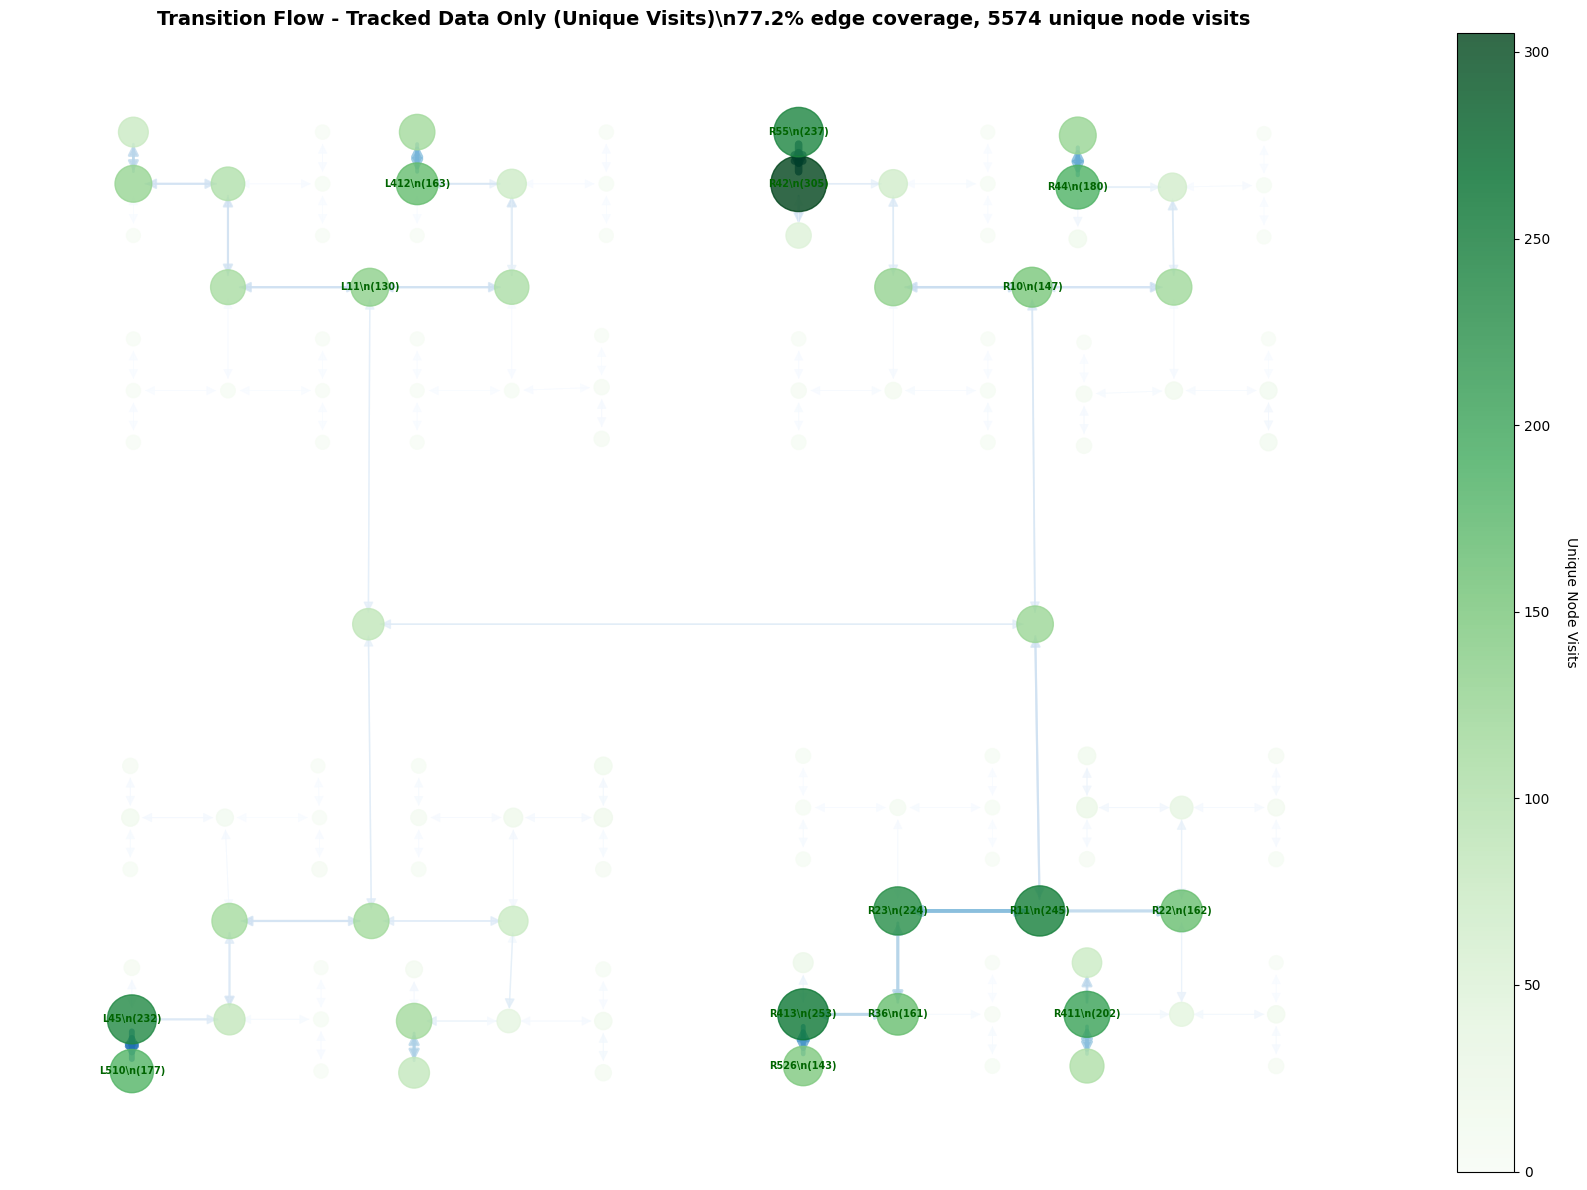

\nTracked Data Statistics:
  Unique node visits: 5574
  Unique transitions: 5573
  Edges used: 193 / 250 (77.2%)
  Most visited nodes (tracked):
    R42: 305 visits
    R413: 253 visits
    R11: 245 visits
    R55: 237 visits
    L45: 232 visits
    R23: 224 visits
    R411: 202 visits
    R44: 180 visits
    L510: 177 visits
    L412: 163 visits
\n  Most used edges (tracked):
    R42 → R55: 237 transitions
    R55 → R42: 237 transitions
    L510 → L45: 177 transitions
    L45 → L510: 177 transitions
    R413 → R526: 143 transitions
    R526 → R413: 138 transitions
    R59 → R44: 122 transitions
    R44 → R59: 122 transitions
    L412 → L525: 112 transitions
    L525 → L412: 112 transitions


In [81]:
# Plot 1: Tracked Data Only - Unique Visits
fig, ax = plt.subplots(figsize=(16, 12))

# Calculate edge widths and colors based on unique transition counts
edge_counts = {}
for edge in graph.edges():
    count = tracked_counts['edge_transitions'].get(edge, 0)
    edge_counts[edge] = count

max_edge_count = max(edge_counts.values()) if edge_counts.values() and max(edge_counts.values()) > 0 else 1
edge_widths = [0.5 + (edge_counts.get(e, 0) / max_edge_count) * 5 for e in graph.edges()]
edge_colors = [edge_counts.get(e, 0) for e in graph.edges()]

# Draw edges
edges = nx.draw_networkx_edges(graph, node_positions,
                               width=edge_widths,
                               edge_color=edge_colors,
                               edge_cmap=plt.cm.Blues,
                               edge_vmin=0,
                               edge_vmax=max(edge_colors) if edge_colors else 1,
                               alpha=0.7,
                               ax=ax,
                               arrowsize=15)

# Node sizes based on unique visit counts
node_visit_counts = [tracked_counts['node_visits'].get(str(node), 0) for node in graph.nodes()]
max_node_visits = max(node_visit_counts) if node_visit_counts else 1
node_sizes = [100 + (count / max_node_visits) * 1500 for count in node_visit_counts]

# Draw nodes
nodes = nx.draw_networkx_nodes(graph, node_positions,
                              node_color=node_visit_counts,
                              node_size=node_sizes,
                              cmap='Greens',
                              vmin=0,
                              vmax=max(node_visit_counts) if node_visit_counts else 1,
                              alpha=0.8,
                              ax=ax)

# Add colorbar
cbar_nodes = plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Unique Node Visits', rotation=270, labelpad=20)

# Draw labels for most visited nodes
top_nodes = sorted(tracked_counts['node_visits'].items(), key=lambda x: x[1], reverse=True)[:15]
top_node_labels = {n: f"{n}\\n({c})" for n, c in top_nodes}
nx.draw_networkx_labels(graph, node_positions,
                       labels=top_node_labels,
                       font_size=7,
                       font_color='darkgreen',
                       font_weight='bold',
                       ax=ax)

# Calculate statistics
edges_used = sum(1 for c in edge_counts.values() if c > 0)
edge_coverage = (edges_used / len(list(graph.edges())) * 100) if graph.edges() else 0

ax.set_title(f'Transition Flow - Tracked Data Only (Unique Visits)\\n{edge_coverage:.1f}% edge coverage, {tracked_counts["total_node_visits"]} unique node visits', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"\\nTracked Data Statistics:")
print(f"  Unique node visits: {tracked_counts['total_node_visits']}")
print(f"  Unique transitions: {tracked_counts['total_transitions']}")
print(f"  Edges used: {edges_used} / {len(list(graph.edges()))} ({edge_coverage:.1f}%)")
print(f"  Most visited nodes (tracked):")
for node, count in top_nodes[:10]:
    print(f"    {node}: {count} visits")
print(f"\\n  Most used edges (tracked):")
sorted_edges = sorted(edge_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for (from_n, to_n), count in sorted_edges:
    if count > 0:
        print(f"    {from_n} → {to_n}: {count} transitions")

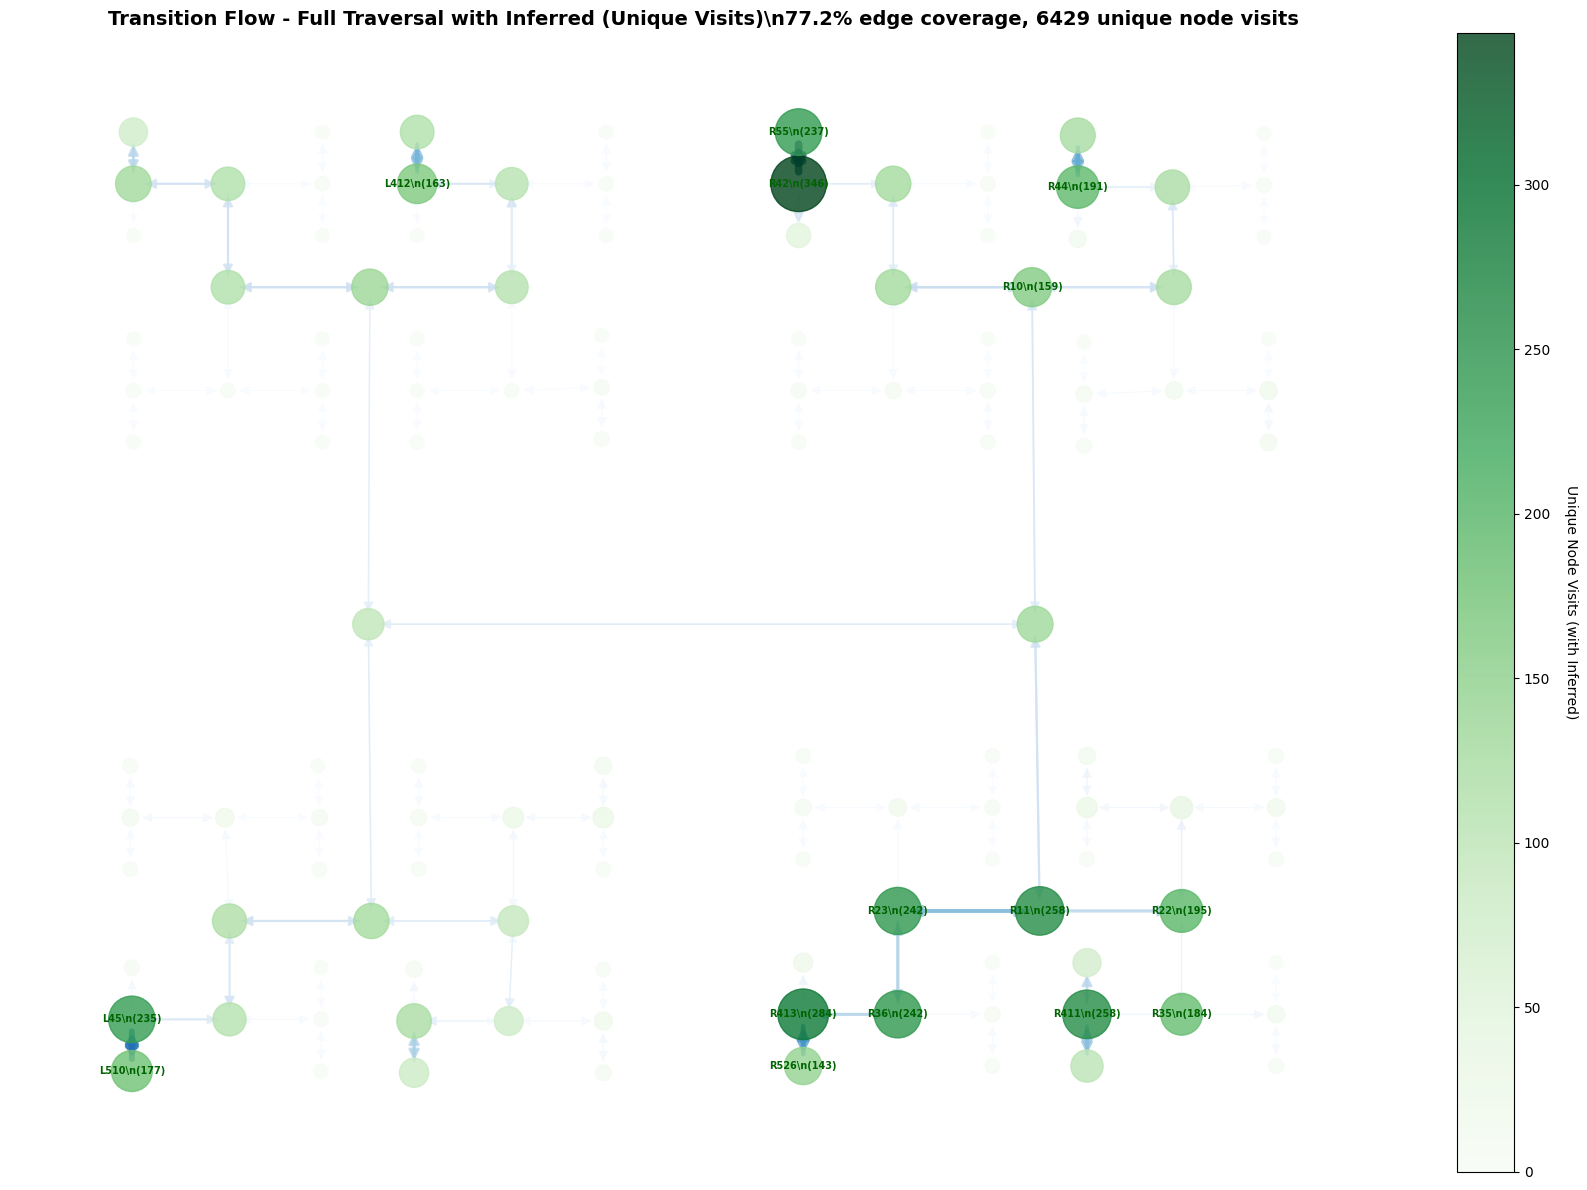

\nFull Traversal Statistics (with Inferred):
  Unique node visits: 6429
  Unique transitions: 4992
  Edges used: 193 / 250 (77.2%)
  Most visited nodes (full):
    R42: 346 visits
    R413: 284 visits
    R11: 258 visits
    R411: 258 visits
    R23: 242 visits
    R36: 242 visits
    R55: 237 visits
    L45: 235 visits
    R22: 195 visits
    R44: 191 visits
\n  Most used edges (full):
    R42 → R55: 237 transitions
    R55 → R42: 237 transitions
    L510 → L45: 177 transitions
    L45 → L510: 177 transitions
    R413 → R526: 143 transitions
    R526 → R413: 138 transitions
    R59 → R44: 122 transitions
    R44 → R59: 122 transitions
    L412 → L525: 112 transitions
    L525 → L412: 112 transitions
\nComparison (Inferred vs Tracked):
  Additional node visits from inferred: 855
  Additional transitions from inferred: -581
  Percentage of visits that are inferred: 13.3%


In [82]:
# Plot 2: Full Traversal (Including Inferred) - Unique Visits
fig, ax = plt.subplots(figsize=(16, 12))

# Calculate edge widths and colors based on unique transition counts (including inferred)
edge_counts_full = {}
for edge in graph.edges():
    count = full_counts['edge_transitions'].get(edge, 0)
    edge_counts_full[edge] = count

max_edge_count_full = max(edge_counts_full.values()) if edge_counts_full.values() and max(edge_counts_full.values()) > 0 else 1
edge_widths_full = [0.5 + (edge_counts_full.get(e, 0) / max_edge_count_full) * 5 for e in graph.edges()]
edge_colors_full = [edge_counts_full.get(e, 0) for e in graph.edges()]

# Draw edges
edges = nx.draw_networkx_edges(graph, node_positions,
                               width=edge_widths_full,
                               edge_color=edge_colors_full,
                               edge_cmap=plt.cm.Blues,
                               edge_vmin=0,
                               edge_vmax=max(edge_colors_full) if edge_colors_full else 1,
                               alpha=0.7,
                               ax=ax,
                               arrowsize=15)

# Node sizes based on unique visit counts (including inferred)
node_visit_counts_full = [full_counts['node_visits'].get(str(node), 0) for node in graph.nodes()]
max_node_visits_full = max(node_visit_counts_full) if node_visit_counts_full else 1
node_sizes_full = [100 + (count / max_node_visits_full) * 1500 for count in node_visit_counts_full]

# Draw nodes
nodes = nx.draw_networkx_nodes(graph, node_positions,
                              node_color=node_visit_counts_full,
                              node_size=node_sizes_full,
                              cmap='Greens',
                              vmin=0,
                              vmax=max(node_visit_counts_full) if node_visit_counts_full else 1,
                              alpha=0.8,
                              ax=ax)

# Add colorbar
cbar_nodes = plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Unique Node Visits (with Inferred)', rotation=270, labelpad=20)

# Draw labels for most visited nodes
top_nodes_full = sorted(full_counts['node_visits'].items(), key=lambda x: x[1], reverse=True)[:15]
top_node_labels_full = {n: f"{n}\\n({c})" for n, c in top_nodes_full}
nx.draw_networkx_labels(graph, node_positions,
                       labels=top_node_labels_full,
                       font_size=7,
                       font_color='darkgreen',
                       font_weight='bold',
                       ax=ax)

# Calculate statistics
edges_used_full = sum(1 for c in edge_counts_full.values() if c > 0)
edge_coverage_full = (edges_used_full / len(list(graph.edges())) * 100) if graph.edges() else 0

ax.set_title(f'Transition Flow - Full Traversal with Inferred (Unique Visits)\\n{edge_coverage_full:.1f}% edge coverage, {full_counts["total_node_visits"]} unique node visits', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print(f"\\nFull Traversal Statistics (with Inferred):")
print(f"  Unique node visits: {full_counts['total_node_visits']}")
print(f"  Unique transitions: {full_counts['total_transitions']}")
print(f"  Edges used: {edges_used_full} / {len(list(graph.edges()))} ({edge_coverage_full:.1f}%)")
print(f"  Most visited nodes (full):")
for node, count in top_nodes_full[:10]:
    print(f"    {node}: {count} visits")
print(f"\\n  Most used edges (full):")
sorted_edges_full = sorted(edge_counts_full.items(), key=lambda x: x[1], reverse=True)[:10]
for (from_n, to_n), count in sorted_edges_full:
    if count > 0:
        print(f"    {from_n} → {to_n}: {count} transitions")

# Print comparison
print(f"\\nComparison (Inferred vs Tracked):")
print(f"  Additional node visits from inferred: {full_counts['total_node_visits'] - tracked_counts['total_node_visits']}")
print(f"  Additional transitions from inferred: {full_counts['total_transitions'] - tracked_counts['total_transitions']}")
inferred_percentage = ((full_counts['total_node_visits'] - tracked_counts['total_node_visits']) / full_counts['total_node_visits'] * 100) if full_counts['total_node_visits'] > 0 else 0
print(f"  Percentage of visits that are inferred: {inferred_percentage:.1f}%")

## Save All Visualizations

Save all the generated plots to a dedicated output folder.

In [79]:
# Extract session name from results
session_path = Path(results['session_results'][0]['session_path'])
session_name = session_path.name

# Create output directory for this session
output_dir = Path('resources/outputs') / f'plots_{session_name}_corrected'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving plots to: {output_dir}")
print("=" * 70)

# Re-generate and save all plots
# 1. Jump events over time and distance histogram
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

finite_mask = df_jumps['distance'] != float('inf')
ax1 = axes[0]
ax1.scatter(df_jumps[finite_mask]['time_sec'], 
           df_jumps[finite_mask]['distance'], 
           alpha=0.5, s=30, c='red')
ax1.set_xlabel('Time (seconds)', fontsize=11)
ax1.set_ylabel('Jump Distance (nodes)', fontsize=11)
ax1.set_title('Jump Events Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(df_jumps[finite_mask]['distance'], bins=range(2, int(df_finite['distance'].max())+2), 
        alpha=0.7, color='steelblue', edgecolor='black')
ax2.set_xlabel('Jump Distance (nodes)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Jump Distances', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(output_dir / '01_jump_events_timeline.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 01_jump_events_timeline.png")

# 2. Jump rate over time bins
plt.figure(figsize=(12, 5))
bin_centers = [(b.left + b.right) / 2 / 60 for b in jumps_per_min.index]
plt.bar(bin_centers, jumps_per_min.values, width=(bin_size_sec/60)*0.8, 
        alpha=0.7, color='coral', edgecolor='black')
plt.xlabel('Time (minutes)', fontsize=11)
plt.ylabel('Jump Rate (jumps/minute)', fontsize=11)
plt.title('Jump Rate Over Time (5-minute bins)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(output_dir / '02_jump_rate_over_time.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 02_jump_rate_over_time.png")

# 3. Graph structure with jump transitions
fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_edges(graph, node_positions, 
                       edge_color='lightgray', 
                       width=1, 
                       alpha=0.5,
                       ax=ax)

nx.draw_networkx_nodes(graph, node_positions,
                      node_color='lightblue',
                      node_size=200,
                      alpha=0.7,
                      ax=ax)

if jumps['jump_events']:
    jump_from_nodes = set([e['from_node'] for e in jumps['jump_events']])
    jump_to_nodes = set([e['to_node'] for e in jumps['jump_events']])
    
    if jump_from_nodes:
        from_pos = {n: node_positions[n] for n in jump_from_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, from_pos,
                              nodelist=list(jump_from_nodes),
                              node_color='red',
                              node_size=300,
                              alpha=0.8,
                              label='Jump sources',
                              ax=ax)
    
    if jump_to_nodes:
        to_pos = {n: node_positions[n] for n in jump_to_nodes if n in node_positions}
        nx.draw_networkx_nodes(graph, to_pos,
                              nodelist=list(jump_to_nodes),
                              node_color='orange',
                              node_size=300,
                              alpha=0.8,
                              label='Jump destinations',
                              ax=ax)
    
    for event in jumps['jump_events'][:100]:
        from_node = event['from_node']
        to_node = event['to_node']
        
        if from_node in node_positions and to_node in node_positions:
            from_pos = node_positions[from_node]
            to_pos = node_positions[to_node]
            
            ax.annotate('', xy=to_pos, xytext=from_pos,
                       arrowprops=dict(arrowstyle='->', 
                                     color='red', 
                                     lw=1.5,
                                     alpha=0.4))

nx.draw_networkx_labels(graph, node_positions,
                       font_size=6,
                       font_color='black',
                       ax=ax)

ax.set_title(f'Graph Structure with Jump Transitions\n{len(jumps["jump_events"])} jumps detected', 
            fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / '03_graph_with_jumps.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 03_graph_with_jumps.png")

# 4. Jump activity heat map
fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_edges(graph, node_positions,
                       edge_color='lightgray',
                       width=1,
                       alpha=0.3,
                       ax=ax)

nodes_drawn = nx.draw_networkx_nodes(graph, node_positions,
                                    node_color=node_colors,
                                    node_size=node_sizes,
                                    cmap='YlOrRd',
                                    vmin=0,
                                    vmax=max(node_colors) if node_colors else 1,
                                    alpha=0.8,
                                    ax=ax)

cbar = plt.colorbar(nodes_drawn, ax=ax)
cbar.set_label('Number of Jumps Involving Node', rotation=270, labelpad=20)

high_activity_nodes = {n: c for n, c in jump_counts.items() if c > np.percentile(list(jump_counts.values()), 75)}
if high_activity_nodes:
    labels = {n: f"{n}\n({c})" for n, c in high_activity_nodes.items()}
    nx.draw_networkx_labels(graph, node_positions,
                           labels=labels,
                           font_size=7,
                           font_color='black',
                           ax=ax)

ax.set_title('Jump Activity Heat Map\nNode size and color indicate jump frequency', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / '04_jump_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 04_jump_heatmap.png")

# 5. Transition flow visualization
fig, ax = plt.subplots(figsize=(16, 12))

edge_counts = {}
for (from_node, to_node), count in flow['transition_matrix'].items():
    if graph.has_edge(from_node, to_node):
        edge_counts[(from_node, to_node)] = count

max_count = max(edge_counts.values()) if edge_counts else 1
edge_widths = [1 + (edge_counts.get(e, 0) / max_count) * 5 for e in graph.edges()]
edge_colors_flow = [edge_counts.get(e, 0) for e in graph.edges()]

edges = nx.draw_networkx_edges(graph, node_positions,
                               width=edge_widths,
                               edge_color=edge_colors_flow,
                               edge_cmap=plt.cm.Blues,
                               edge_vmin=0,
                               edge_vmax=max(edge_colors_flow) if edge_colors_flow else 1,
                               alpha=0.7,
                               ax=ax)

node_colors_flow = [flow['node_visit_counts'].get(str(node), 0) for node in graph.nodes()]
node_sizes_flow = [100 + flow['node_visit_counts'].get(str(node), 0) * 0.5 for node in graph.nodes()]

nodes = nx.draw_networkx_nodes(graph, node_positions,
                              node_color=node_colors_flow,
                              node_size=node_sizes_flow,
                              cmap='Greens',
                              vmin=0,
                              vmax=max(node_colors_flow) if node_colors_flow else 1,
                              alpha=0.8,
                              ax=ax)

cbar_nodes = plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Node Visits', rotation=270, labelpad=20)

top_nodes = sorted(flow['node_visit_counts'].items(), key=lambda x: x[1], reverse=True)[:15]
top_node_labels = {n: f"{n}" for n, c in top_nodes}
nx.draw_networkx_labels(graph, node_positions,
                       labels=top_node_labels,
                       font_size=7,
                       font_color='darkgreen',
                       font_weight='bold',
                       ax=ax)

ax.set_title(f'Transition Flow Visualization\n{flow["edge_coverage"]}% edge coverage, {flow["total_transitions"]} transitions', 
            fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / '05_transition_flow.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 05_transition_flow.png")

print("=" * 70)
print(f"All plots saved successfully to: {output_dir}")
print(f"Total files: 5 PNG images at 300 DPI")

Saving plots to: resources/outputs/plots_session_NPC1_21_08_2025_corrected
✓ Saved: 01_jump_events_timeline.png
✓ Saved: 02_jump_rate_over_time.png
✓ Saved: 03_graph_with_jumps.png
✓ Saved: 04_jump_heatmap.png
✓ Saved: 05_transition_flow.png
All plots saved successfully to: resources/outputs/plots_session_NPC1_21_08_2025_corrected
Total files: 5 PNG images at 300 DPI
